# Analyse Descriptive des Logs Sécurité

Ce notebook présente une analyse descriptive des logs de sécurité brutes. 
Les étapes suivantes sont réalisées :
1. Chargement des données
2. Classement des règles
3. Histogramme des protocoles
4. Top règles par protocole (UDP/TCP)
5. Analyse approfondie TCP (Règles vs Ports vs Actions)
6. Graphiques de sécurité complémentaires

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de l'affichage
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Chargement des données

In [11]:
# Chemin vers le fichier log
file_path = '../data/brute/log_export.log'

# Chargement optimisé d'un fichier texte volumineux (2Go)
# On lit ligne par ligne et on ne garde que celles qui correspondent à la période demandée.
# Période : Novembre 2025 à Février 2026 inclus
# Astuce : La date est au début de la ligne, on peut filtrer sur les chaines de caractères.

target_prefixes = ('2025-11', '2025-12', '2026-01', '2026-02')

filtered_data = []

try:
    # Ouverture du fichier et lecture ligne par ligne pour économiser la RAM
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            # Vérification rapide si la ligne commence par une des dates cibles
            if line.startswith(target_prefixes):
                # On nettoie la fin de ligne et on split directement
                filtered_data.append(line.strip().split(';'))
except FileNotFoundError:
    print(f"Le fichier {file_path} n'a pas été trouvé. Vérifiez le chemin.")
    filtered_data = []


# Définition des noms de colonnes (basé sur l'analyse précédente)
column_names = [
    'timestamp', 'src_ip', 'dst_ip', 'proto', 'src_port', 'dst_port', 
    'rule_id', 'action', 'interface', 'col_9', 'proto_num'
]

# Création du DataFrame si des données ont été trouvées
if filtered_data:
    df = pd.DataFrame(filtered_data, columns=column_names)

    # Conversion des types numériques
    for col in ['src_port', 'dst_port', 'rule_id', 'proto_num']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Conversion timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Libération de la mémoire
    del filtered_data

    print(f"Nombre de lignes chargées : {len(df)}")
    print(df.info())
    display(df.head())
else:
    print("Aucune donnée chargée pour la période spécifiée.")
    df = pd.DataFrame() # DataFrame vide pour éviter les crashes suivants


Nombre de lignes chargées : 4572903
<class 'pandas.DataFrame'>
RangeIndex: 4572903 entries, 0 to 4572902
Data columns (total 11 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[us]
 1   src_ip     str           
 2   dst_ip     str           
 3   proto      str           
 4   src_port   int64         
 5   dst_port   int64         
 6   rule_id    int64         
 7   action     str           
 8   interface  str           
 9   col_9      str           
 10  proto_num  int64         
dtypes: datetime64[us](1), int64(4), str(6)
memory usage: 551.5 MB
None


,timestamp,src_ip,dst_ip,proto,src_port,dst_port,rule_id,action,interface,col_9,proto_num
0,2025-11-12 09:56:37,77.90.185.64,159.84.146.99,TCP,55366,65153,999,DENY,eth0,,6
1,2025-11-12 09:56:37,47.128.20.252,159.84.146.99,TCP,14436,443,1,PERMIT,eth0,,6
2,2025-11-12 09:56:38,23.22.35.162,159.84.146.99,TCP,55973,443,1,PERMIT,eth0,,6
3,2025-11-12 09:56:39,79.124.60.150,159.84.146.99,TCP,53744,56283,999,DENY,eth0,,6
4,2025-11-12 09:56:39,47.128.20.252,159.84.146.99,TCP,25404,443,1,PERMIT,eth0,,6


In [13]:
df.drop(columns=['col_9', "proto_num"], inplace=True)

## 2. Classement des règles les plus utilisées

C:\Users\olivi\AppData\Local\Temp\ipykernel_30912\3209808053.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_rules.index.astype(str), y=top_rules.values, palette='viridis')


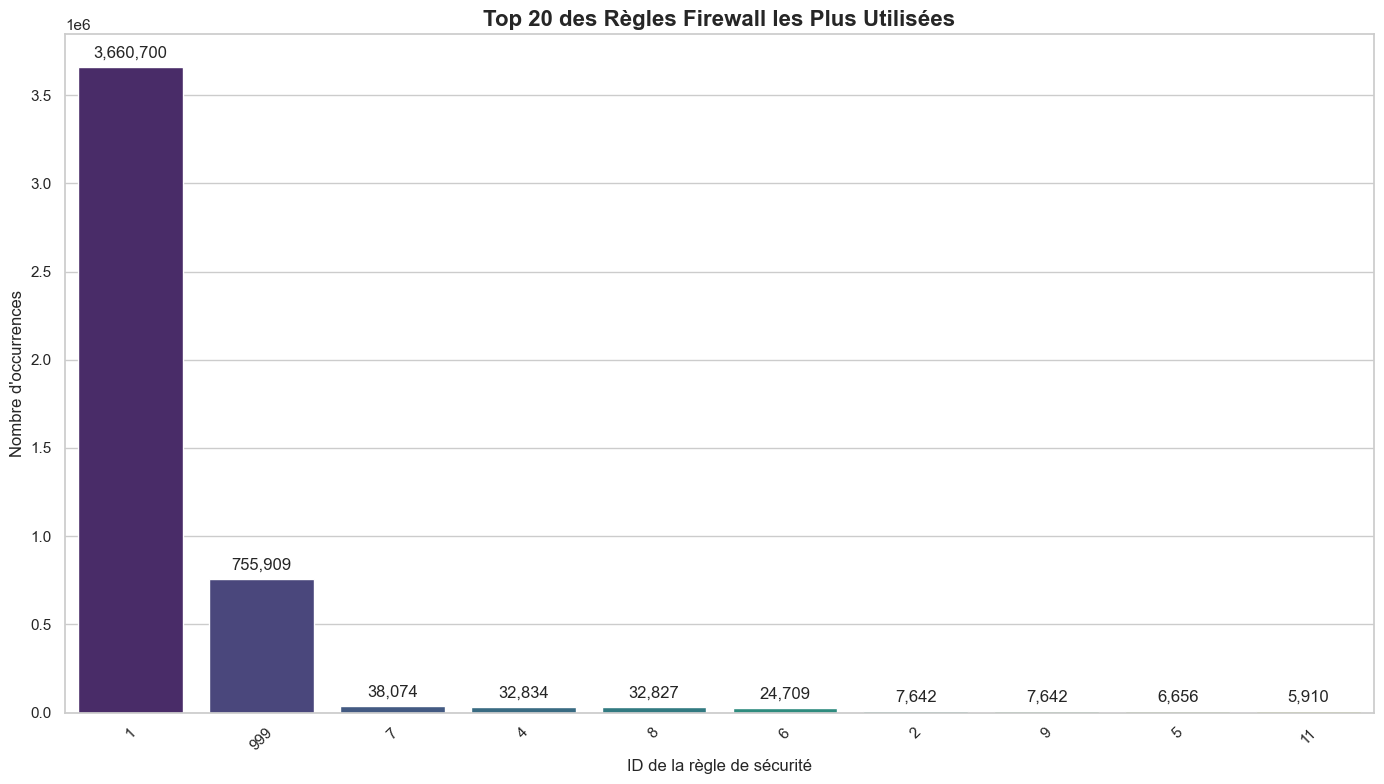

CLASSEMENT DES RÈGLES FIREWALL LES PLUS UTILISÉES
 1. Règle 1: 3,660,700 occurrences (80.05%)
 2. Règle 999: 755,909 occurrences (16.53%)
 3. Règle 7: 38,074 occurrences (0.83%)
 4. Règle 4: 32,834 occurrences (0.72%)
 5. Règle 8: 32,827 occurrences (0.72%)
 6. Règle 6: 24,709 occurrences (0.54%)
 7. Règle 2: 7,642 occurrences (0.17%)
 8. Règle 9: 7,642 occurrences (0.17%)
 9. Règle 5: 6,656 occurrences (0.15%)
10. Règle 11: 5,910 occurrences (0.13%)

Total des logs analysés : 4,572,903


In [16]:
# Classement des règles les plus utilisées
if len(df) > 0:
    # La colonne rule_id contient les IDs des règles firewall
    rule_col = 'rule_id'
    
    if rule_col in df.columns:
        top_rules = df[rule_col].value_counts().head(20)
        
        plt.figure(figsize=(14, 8))
        ax = sns.barplot(x=top_rules.index.astype(str), y=top_rules.values, palette='viridis')
        plt.title('Top 20 des Règles Firewall les Plus Utilisées', fontsize=16, fontweight='bold')
        plt.xlabel('ID de la règle de sécurité')
        plt.ylabel('Nombre d\'occurrences')
        plt.xticks(rotation=45)
        
        # Ajouter les valeurs sur les barres
        for i, v in enumerate(top_rules.values):
            ax.text(i, v + max(top_rules.values) * 0.01, f'{v:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("=" * 60)
        print("CLASSEMENT DES RÈGLES FIREWALL LES PLUS UTILISÉES")
        print("=" * 60)
        for idx, (rule, count) in enumerate(top_rules.items(), 1):
            percentage = (count / len(df)) * 100
            print(f"{idx:2d}. Règle {rule}: {count:,} occurrences ({percentage:.2f}%)")
        
        print(f"\nTotal des logs analysés : {len(df):,}")
    else:
        print("Colonne de règle 'rule_id' non trouvée. Colonnes disponibles :", df.columns.tolist())
else:
    print("Aucune donnée chargée.")

## 3. Histogramme des protocoles (Déduction TCP/UDP)

Protocoles détectés :
protocol_deduced
TCP    4572903
Name: count, dtype: int64


C:\Users\olivi\AppData\Local\Temp\ipykernel_30912\3265439322.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=protocol_counts.index, y=protocol_counts.values, palette='Set2')


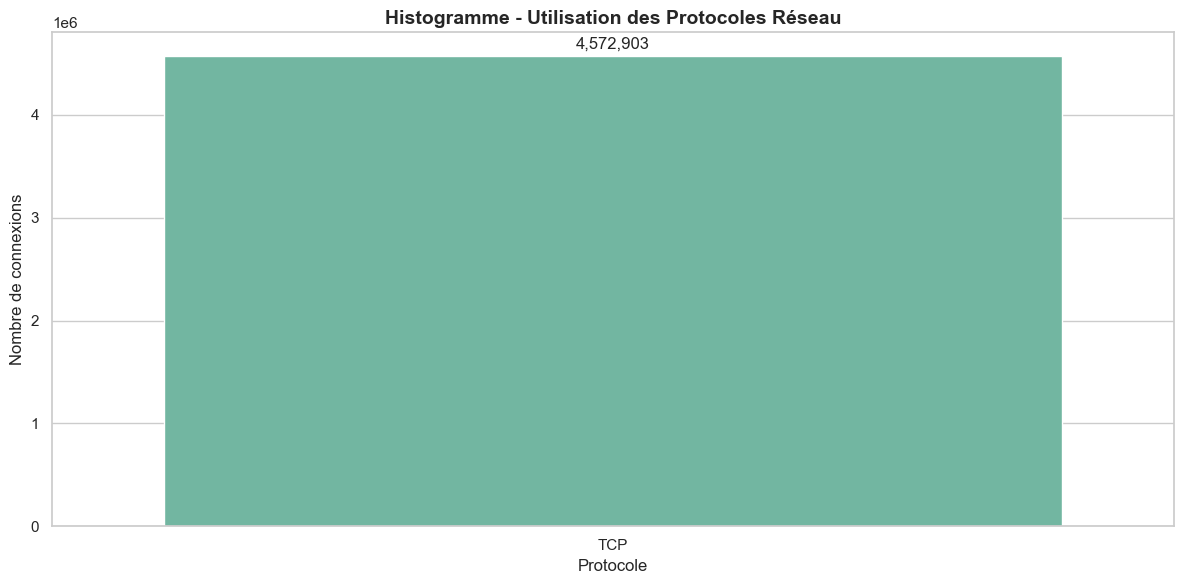


Répartition détaillée des protocoles :
----------------------------------------
TCP  : 4,572,903 connexions (100.0%)
----------------------------------------
Total: 4,572,903 connexions (100.0%)


In [29]:
# Déduction du protocole basée sur les données observées  
if len(df) > 0:
    # Fonction pour déduire le protocole par port si nécessaire
    def deduce_protocol_from_port(dst_port):
        """Déduit le protocole basé sur le port de destination"""
        try:
            port = int(dst_port)
            # Ports UDP bien connus
            udp_ports = [53, 67, 68, 69, 123, 161, 162, 500, 514, 520, 1194, 4500, 1812, 1813]
            if port in udp_ports:
                return 'UDP'
            else:
                return 'TCP'  # Par défaut TCP pour les autres ports
        except (ValueError, TypeError):
            return 'Autre'
    
    # La colonne 'proto' contient directement le protocole (TCP/UDP/etc.)
    # On nettoie d'abord la colonne
    df['proto_clean'] = df['proto'].astype(str).str.upper().str.strip()
    
    # Si proto contient déjà TCP/UDP/ICMP, on l'utilise directement
    df['protocol_deduced'] = df['proto_clean']
    
    # Pour les cas non reconnus, déduire par port
    mask_unknown = ~df['protocol_deduced'].isin(['TCP', 'UDP', 'ICMP'])
    if mask_unknown.sum() > 0:
        df.loc[mask_unknown, 'protocol_deduced'] = df.loc[mask_unknown, 'dst_port'].apply(deduce_protocol_from_port)
        
    print(f"Protocoles détectés :")
    print(df['protocol_deduced'].value_counts())
    
else:
    df['protocol_deduced'] = []

# Histogramme des protocoles
if len(df) > 0:
    plt.figure(figsize=(12, 6))
    protocol_counts = df['protocol_deduced'].value_counts()
    
    # Graphique en barres
    ax = sns.barplot(x=protocol_counts.index, y=protocol_counts.values, palette='Set2')
    plt.title('Histogramme - Utilisation des Protocoles Réseau', fontsize=14, fontweight='bold')
    plt.ylabel('Nombre de connexions')
    plt.xlabel('Protocole')
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(protocol_counts.values):
        ax.text(i, v + max(protocol_counts.values) * 0.01, f'{v:,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Affichage des statistiques
    print("\nRépartition détaillée des protocoles :")
    print("-" * 40)
    total = len(df)
    for proto, count in protocol_counts.items():
        percentage = (count / total) * 100
        print(f"{proto:5}: {count:8,} connexions ({percentage:5.1f}%)")
    print("-" * 40)
    print(f"{'Total':5}: {total:8,} connexions (100.0%)")
else:
    print("Aucune donnée à analyser.")

## 3.5. Analyse géographique des IPs sources

Cette section présente une analyse géographique des adresses IP sources les plus actives, ainsi qu'une analyse de leur répartition temporelle.

In [30]:
# Analyse géographique des 20 IPs les plus actives
import folium
import requests
import time
from collections import Counter

if len(df) > 0:
    print("=" * 60)
    print("ANALYSE GÉOGRAPHIQUE DES IPs SOURCES")
    print("=" * 60)
    
    # Obtenir les 20 IPs les plus actives
    top_20_ips = df['src_ip'].value_counts().head(20)
    
    print(f"Géolocalisation de {len(top_20_ips)} adresses IP...")
    
    # Fonction pour obtenir la géolocalisation d'une IP
    def get_ip_location(ip):
        """Obtient la géolocalisation d'une IP via l'API ip-api.com (gratuite)"""
        try:
            # API gratuite avec limite de 45 requêtes/minute
            response = requests.get(f"http://ip-api.com/json/{ip}", timeout=5)
            if response.status_code == 200:
                data = response.json()
                if data['status'] == 'success':
                    return {
                        'ip': ip,
                        'country': data.get('country', 'Unknown'),
                        'country_code': data.get('countryCode', 'XX'),
                        'region': data.get('regionName', 'Unknown'),
                        'city': data.get('city', 'Unknown'),
                        'lat': data.get('lat', 0),
                        'lon': data.get('lon', 0),
                        'isp': data.get('isp', 'Unknown')
                    }
            return None
        except Exception as e:
            print(f"Erreur pour {ip}: {e}")
            return None
    
    # Géolocaliser les IPs (avec délai pour respecter les limites de l'API)
    ip_locations = []
    for i, (ip, count) in enumerate(top_20_ips.items()):
        print(f"Géolocalisation {i+1}/20: {ip}...")
        location = get_ip_location(ip)
        if location:
            location['activity_count'] = count
            ip_locations.append(location)
        
        # Délai pour respecter les limites de l'API (45 req/min = ~1.3s entre chaque)
        if i < len(top_20_ips) - 1:  # Pas de délai après la dernière IP
            time.sleep(1.5)
    
    if ip_locations:
        # Créer la carte interactive
        print(f"\nCréation de la carte interactive avec {len(ip_locations)} IPs géolocalisées...")
        
        # Centre de la carte (centré sur l'Europe par défaut)
        center_lat = 50.0
        center_lon = 10.0
        
        # Créer la carte
        world_map = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=3,
            tiles='OpenStreetMap'
        )
        
        # Statistiques par pays
        countries = Counter([loc['country'] for loc in ip_locations])
        
        # Ajouter les marqueurs pour chaque IP
        for loc in ip_locations:
            # Taille du marqueur basée sur l'activité
            radius = min(max(loc['activity_count'] / 1000, 5), 25)
            
            # Couleur basée sur le niveau d'activité
            if loc['activity_count'] > 10000:
                color = 'red'
            elif loc['activity_count'] > 5000:
                color = 'orange'
            else:
                color = 'blue'
            
            # Popup avec détails
            popup_text = f"""
            <b>IP:</b> {loc['ip']}<br>
            <b>Pays:</b> {loc['country']}<br>
            <b>Région:</b> {loc['region']}<br>
            <b>Ville:</b> {loc['city']}<br>
            <b>ISP:</b> {loc['isp']}<br>
            <b>Activité:</b> {loc['activity_count']:,} connexions
            """
            
            folium.CircleMarker(
                location=[loc['lat'], loc['lon']],
                radius=radius,
                popup=folium.Popup(popup_text, max_width=300),
                color=color,
                fillColor=color,
                fillOpacity=0.7,
                weight=2
            ).add_to(world_map)
        
        # Ajouter une légende
        legend_html = '''
        <div style="position: fixed; 
                    bottom: 50px; left: 50px; width: 200px; height: 120px; 
                    background-color: white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <p><b>Niveau d'activité</b></p>
        <p><i class="fa fa-circle" style="color:red"></i> > 10,000 connexions</p>
        <p><i class="fa fa-circle" style="color:orange"></i> 5,000 - 10,000</p>
        <p><i class="fa fa-circle" style="color:blue"></i> < 5,000</p>
        </div>
        '''
        world_map.get_root().html.add_child(folium.Element(legend_html))
        
        # Sauvegarder la carte
        map_path = 'ip_geolocation_map.html'
        world_map.save(map_path)
        
        print(f"\n✅ Carte sauvegardée : {map_path}")
        
        # Affichage des statistiques
        print("\n" + "=" * 50)
        print("STATISTIQUES GÉOGRAPHIQUES")
        print("=" * 50)
        
        print("\nRépartition par pays :")
        for country, count in countries.most_common():
            percentage = (count / len(ip_locations)) * 100
            print(f"  {country:20}: {count:2d} IPs ({percentage:4.1f}%)")
        
        print("\nTop 10 IPs par localisation :")
        sorted_locations = sorted(ip_locations, key=lambda x: x['activity_count'], reverse=True)
        for i, loc in enumerate(sorted_locations[:10], 1):
            print(f"{i:2d}. {loc['ip']:15} | {loc['country']:15} | {loc['city']:15} | {loc['activity_count']:8,} connexions")
        
        # Afficher la carte dans le notebook (si possible)
        try:
            display(world_map)
        except:
            print(f"\n💡 Ouvrez le fichier '{map_path}' dans votre navigateur pour voir la carte interactive.")
    
    else:
        print("❌ Aucune IP n'a pu être géolocalisée.")
else:
    print("Aucune donnée disponible pour l'analyse géographique.")

ANALYSE GÉOGRAPHIQUE DES IPs SOURCES
Géolocalisation de 20 adresses IP...
Géolocalisation 1/20: 3.224.220.101...
Géolocalisation 2/20: 23.22.35.162...
Géolocalisation 3/20: 52.70.240.171...
Géolocalisation 4/20: 51.79.181.158...
Géolocalisation 5/20: 103.89.91.86...
Géolocalisation 6/20: 103.151.123.241...
Géolocalisation 7/20: 103.139.44.2...
Géolocalisation 8/20: 89.248.165.166...
Géolocalisation 9/20: 23.230.171.181...
Géolocalisation 10/20: 77.90.185.64...
Géolocalisation 11/20: 157.90.182.25...
Géolocalisation 12/20: 66.249.68.7...
Géolocalisation 13/20: 76.167.102.53...
Géolocalisation 14/20: 66.249.68.8...
Géolocalisation 15/20: 51.79.191.240...
Géolocalisation 16/20: 157.90.182.29...
Géolocalisation 17/20: 77.90.185.55...
Géolocalisation 18/20: 66.249.68.70...
Géolocalisation 19/20: 79.124.60.150...
Géolocalisation 20/20: 66.249.68.1...

Création de la carte interactive avec 20 IPs géolocalisées...

✅ Carte sauvegardée : ip_geolocation_map.html

STATISTIQUES GÉOGRAPHIQUES

Répa


ANALYSE TEMPORELLE DES TOP 20 ADRESSES IP SOURCES
Analyse de 2,689,296 connexions des 20 IP sources les plus actives
Période analysée : 2025-11-12 09:56:37 → 2026-02-12 10:08:39

1. DISTRIBUTION HORAIRE GLOBALE
Heures de pic d'activité :
   1h00 : 173,642 connexions
   2h00 : 173,600 connexions
   3h00 : 173,587 connexions


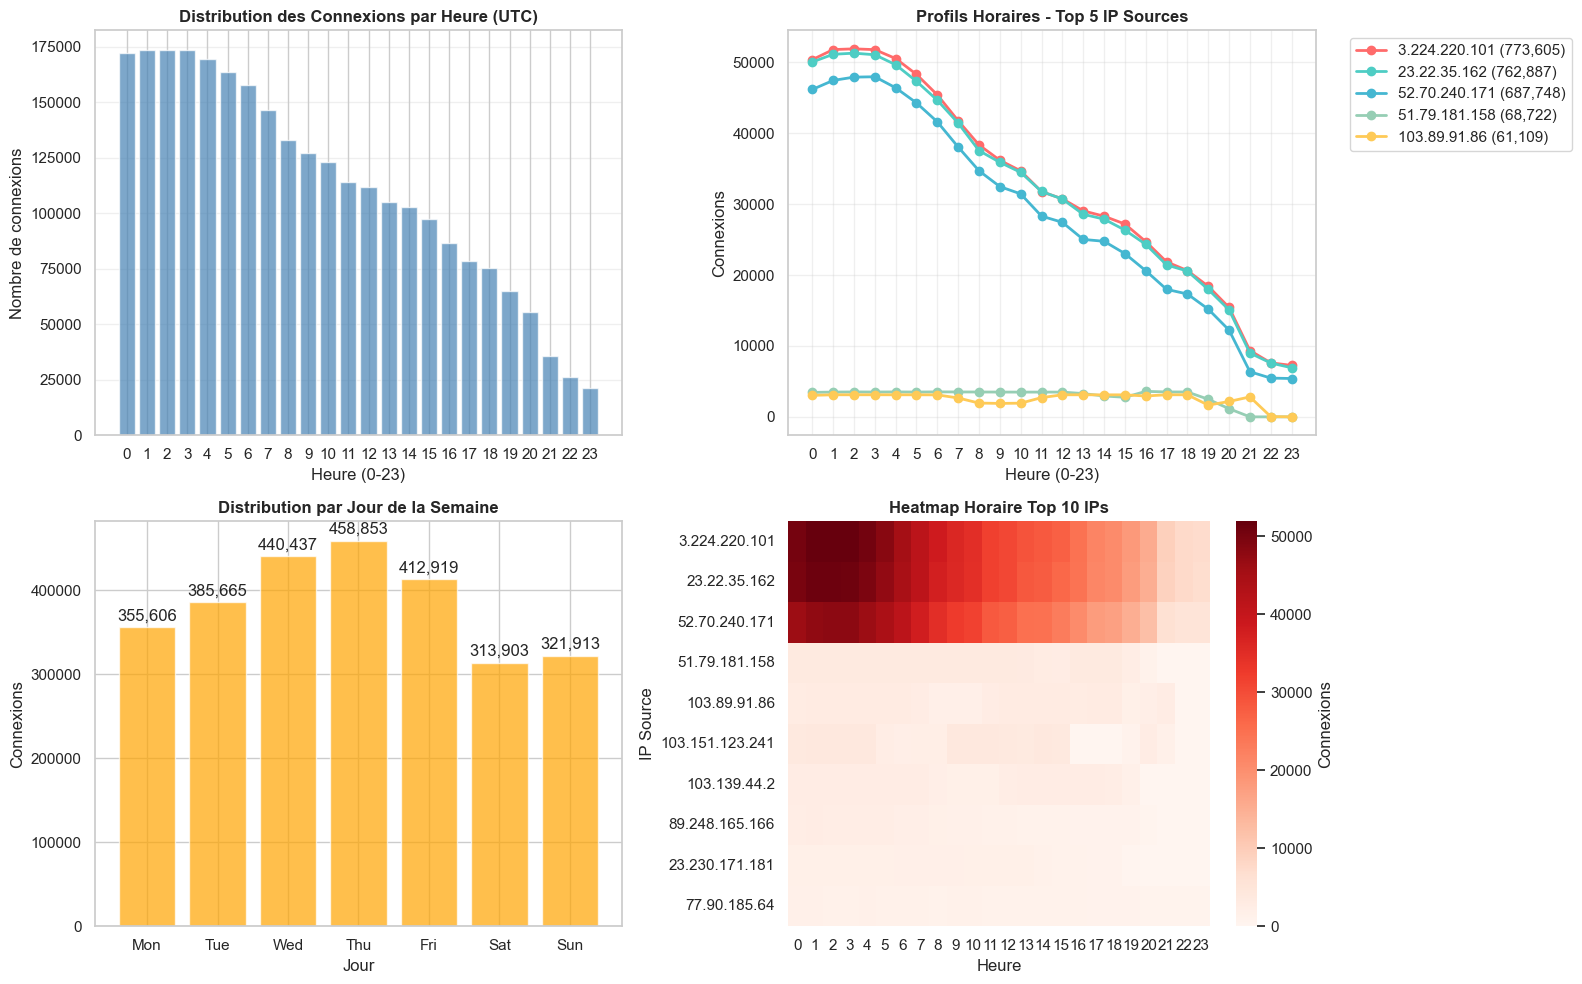


2. ANALYSE PAR ZONES TEMPORELLES APPROXIMATIVES
✅ Analyse temporelle utilisant les fuseaux horaires précis par pays

Répartition des connexions par zone d'activité :
  United States_BusinessHours: 1,425,897 connexions ( 53.0%)
  United States_OffHours   : 898,224 connexions ( 33.4%)
  Vietnam_BusinessHours    : 140,671 connexions (  5.2%)
  Singapore_BusinessHours  :  57,958 connexions (  2.2%)
  Germany_BusinessHours    :  51,024 connexions (  1.9%)
  Vietnam_OffHours         :  30,942 connexions (  1.2%)
  Singapore_OffHours       :  23,942 connexions (  0.9%)
  Netherlands_BusinessHours:  21,407 connexions (  0.8%)
  Germany_OffHours         :  17,859 connexions (  0.7%)
  Netherlands_OffHours     :  12,690 connexions (  0.5%)
  Bulgaria_BusinessHours   :   6,527 connexions (  0.2%)
  Bulgaria_OffHours        :   2,155 connexions (  0.1%)


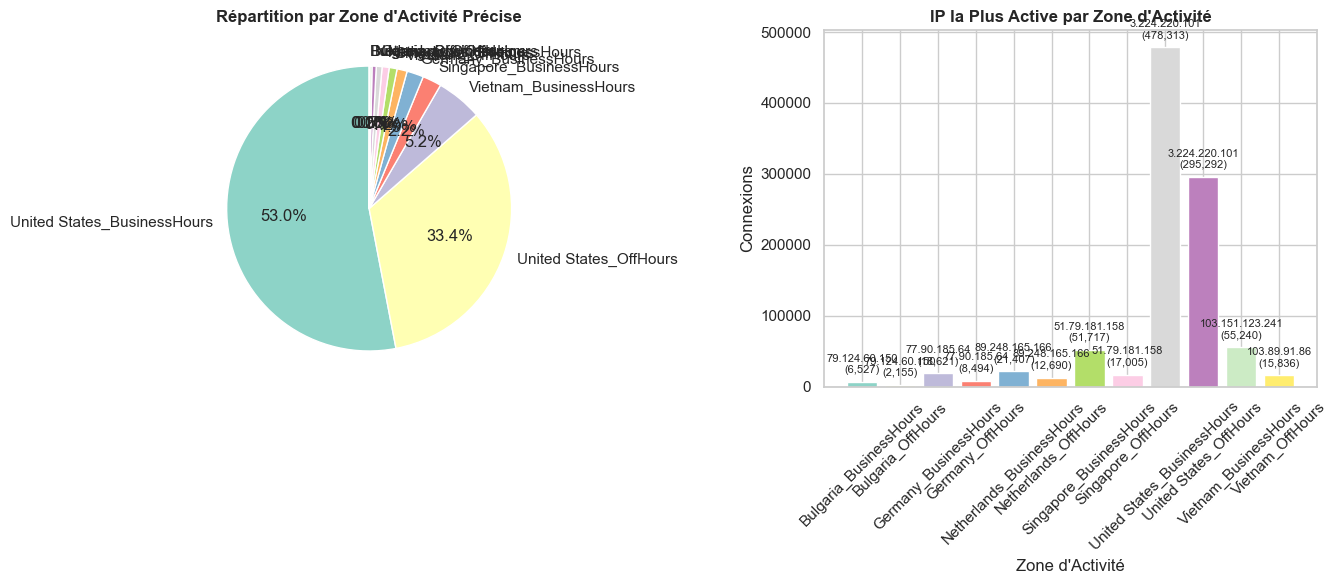


ANALYSE DÉTAILLÉE PAR FUSEAU HORAIRE RÉEL

Activité par pays et fuseau horaire :
Pays                 | UTC  | Total    | Heures Ouv.  | Hors Heures  | % Business
-------------------------------------------------------------------------------------
United States        | UTC-5.0 | 2,324,121 | 1,425,897    | 898,224      | 61.4      %
Vietnam              | UTC+7.0 | 171,613  | 140,671      | 30,942       | 82.0      %
Singapore            | UTC+8.0 | 81,900   | 57,958       | 23,942       | 70.8      %
Germany              | UTC+1.0 | 68,883   | 51,024       | 17,859       | 74.1      %
Netherlands          | UTC+1.0 | 34,097   | 21,407       | 12,690       | 62.8      %
Bulgaria             | UTC+2.0 | 8,682    | 6,527        | 2,155        | 75.2      %

3. STATISTIQUES DÉTAILLÉES PAR ZONE D'ACTIVITÉ

📊 RÉSUMÉ GLOBAL
   Total connexions analysées: 2,689,296
   IPs sources uniques: 20
   Zones d'activité détectées: 12

🌍 1. UNITED STATES_BUSINESSHOURS
   ├─ Connexions totales: 1,425,

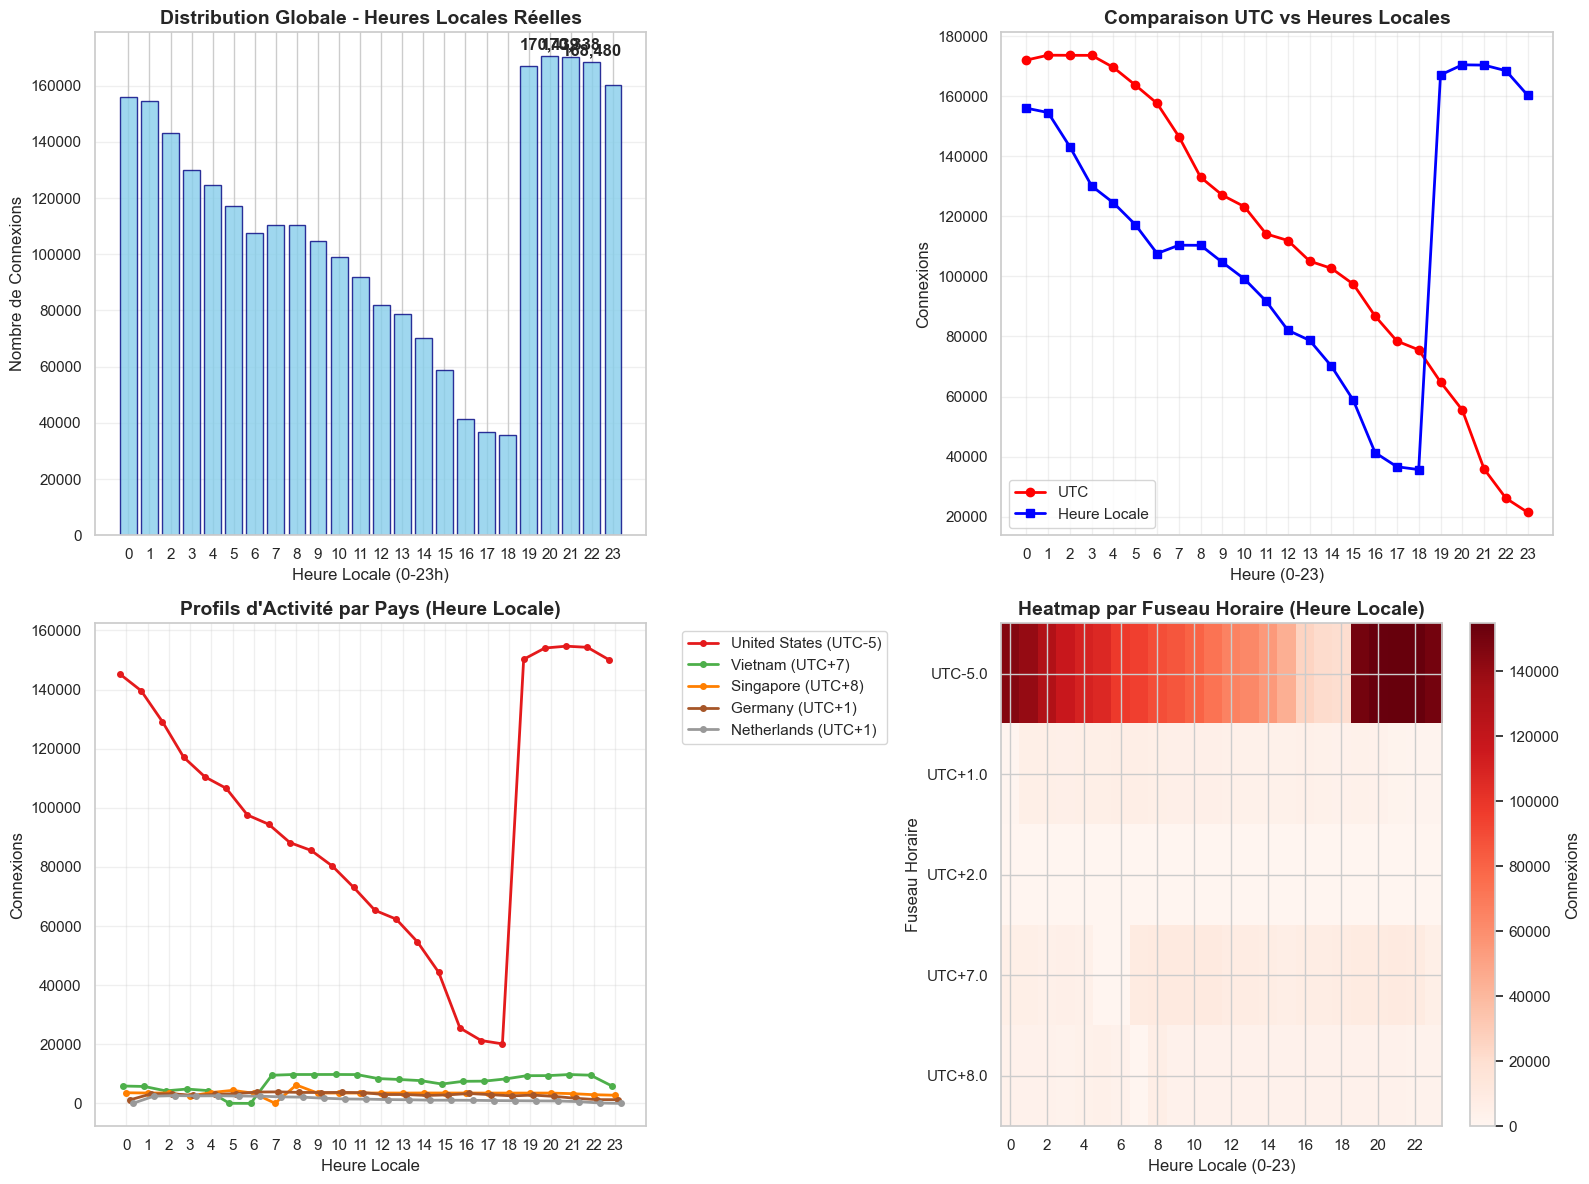


📈 INSIGHTS DES HEURES LOCALES:
   • 63.3% de l'activité en heures ouvrables locales (6h-22h)
   • Pic d'activité globale: 20h00 locale (170,439 connexions)
   • Pays avec forte activité nocturne:
     - United States: 38.6% en heures nocturnes (suspect)
     - Netherlands: 37.2% en heures nocturnes (suspect)
   • 2689296 connexions analysées avec fuseaux horaires précis
   • 6 pays différents représentés

4. CORRÉLATION GÉOGRAPHIQUE ET TEMPORELLE PRÉCISE

📍 3.224.220.101 (United States, UTC-5.0)
   Heure locale de pic: 21h00
   Activité totale: 773,605 connexions
   Pattern: 🔄 Activité mixte jour/nuit (61.8% jour)

📍 23.22.35.162 (United States, UTC-5.0)
   Heure locale de pic: 21h00
   Activité totale: 762,887 connexions
   Pattern: 🔄 Activité mixte jour/nuit (61.8% jour)

📍 52.70.240.171 (United States, UTC-5.0)
   Heure locale de pic: 22h00
   Activité totale: 687,748 connexions
   Pattern: 🔄 Activité mixte jour/nuit (60.9% jour)

📍 51.79.181.158 (Singapore, UTC+8.0)
   Heure local

In [36]:
# Analyse temporelle détaillée des top 20 IP sources
import numpy as np
from datetime import datetime

if len(df) > 0:
    print("\n" + "=" * 65)
    print("ANALYSE TEMPORELLE DES TOP 20 ADRESSES IP SOURCES")
    print("=" * 65)
    
    # Obtenir les 20 IPs sources les plus actives
    top_20_src_ips = df['src_ip'].value_counts().head(20)
    
    try:
        # Vérifier que nous avons les colonnes nécessaires
        if 'timestamp' not in df.columns:
            print("❌ Colonne timestamp manquante pour l'analyse temporelle")
            raise ValueError("Timestamp column required")
        
        # Extraire les informations temporelles
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.day_name()
        df['date'] = df['timestamp'].dt.date
        
        # Filtrer uniquement les données des top 20 IP sources
        top_ips_data = df[df['src_ip'].isin(top_20_src_ips.index)].copy()
        
        print(f"Analyse de {len(top_ips_data):,} connexions des 20 IP sources les plus actives")
        print(f"Période analysée : {df['timestamp'].min()} → {df['timestamp'].max()}")
        
        # === 1. ANALYSE GLOBALE PAR HEURE ===
        print(f"\n{'='*50}")
        print("1. DISTRIBUTION HORAIRE GLOBALE")
        print(f"{'='*50}")
        
        plt.figure(figsize=(16, 10))
        
        # Graphique 1 : Distribution horaire globale
        plt.subplot(2, 2, 1)
        hourly_dist = top_ips_data['hour'].value_counts().sort_index()
        plt.bar(hourly_dist.index, hourly_dist.values, color='steelblue', alpha=0.7)
        plt.title('Distribution des Connexions par Heure (UTC)', fontweight='bold')
        plt.xlabel('Heure (0-23)')
        plt.ylabel('Nombre de connexions')
        plt.xticks(range(0, 24))
        plt.grid(axis='y', alpha=0.3)
        
        # Identifier les heures de pic
        peak_hours = hourly_dist.nlargest(3)
        print(f"Heures de pic d'activité :")
        for hour, count in peak_hours.items():
            print(f"  {hour:2d}h00 : {count:,} connexions")
        
        # === 2. PROFILS INDIVIDUELS DES TOP 5 IPS ===
        plt.subplot(2, 2, 2)
        top_5_ips = top_20_src_ips.head(5)
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
        for i, (ip, total_count) in enumerate(top_5_ips.items()):
            ip_hourly = top_ips_data[top_ips_data['src_ip'] == ip]['hour'].value_counts().reindex(range(24), fill_value=0)
            plt.plot(ip_hourly.index, ip_hourly.values, marker='o', 
                    label=f'{ip} ({total_count:,})', color=colors[i], linewidth=2)
        
        plt.title('Profils Horaires - Top 5 IP Sources', fontweight='bold')
        plt.xlabel('Heure (0-23)')
        plt.ylabel('Connexions')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.xticks(range(0, 24))
        
        # === 3. ANALYSE PAR JOUR DE LA SEMAINE ===
        plt.subplot(2, 2, 3)
        weekly_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        daily_dist = top_ips_data['day_of_week'].value_counts().reindex(weekly_order)
        
        bars = plt.bar(range(len(daily_dist)), daily_dist.values, color='orange', alpha=0.7)
        plt.title('Distribution par Jour de la Semaine', fontweight='bold')
        plt.xlabel('Jour')
        plt.ylabel('Connexions')
        plt.xticks(range(len(daily_dist)), [day[:3] for day in weekly_order])
        
        # Annoter les barres
        for i, v in enumerate(daily_dist.values):
            plt.text(i, v + max(daily_dist.values) * 0.01, f'{v:,}', ha='center', va='bottom')
        
        # === 4. HEATMAP DES ACTIVITÉS ===
        plt.subplot(2, 2, 4)
        
        # Créer une heatmap heure x jour pour les top 10 IPs
        top_10_for_heatmap = top_20_src_ips.head(10)
        
        # Préparer les données pour la heatmap
        heatmap_data = []
        for i, (ip, _) in enumerate(top_10_for_heatmap.items()):
            ip_data = top_ips_data[top_ips_data['src_ip'] == ip]
            hourly_activity = ip_data['hour'].value_counts().reindex(range(24), fill_value=0)
            heatmap_data.append(hourly_activity.values)
        
        # Créer la heatmap
        sns.heatmap(heatmap_data, 
                   yticklabels=[f"{ip}" for ip in top_10_for_heatmap.index],
                   xticklabels=range(24),
                   cmap='Reds',
                   cbar_kws={'label': 'Connexions'})
        plt.title('Heatmap Horaire Top 10 IPs', fontweight='bold')
        plt.xlabel('Heure')
        plt.ylabel('IP Source')
        
        plt.tight_layout()
        plt.show()
        
        # === 5. ANALYSE PAR ZONES TEMPORELLES APPROXIMATIVES ===
        print(f"\n{'='*55}")
        print("2. ANALYSE PAR ZONES TEMPORELLES APPROXIMATIVES")
        print(f"{'='*55}")
        
        # Dictionnaire précis des fuseaux horaires par pays (offset UTC en heures)
        country_timezones = {
            # Europe
            'France': 1, 'Germany': 1, 'Spain': 1, 'Italy': 1, 'Netherlands': 1,
            'Belgium': 1, 'Switzerland': 1, 'Austria': 1, 'Poland': 1, 'Czech Republic': 1,
            'Denmark': 1, 'Sweden': 1, 'Norway': 1, 'Hungary': 1, 'Croatia': 1,
            'Slovakia': 1, 'Slovenia': 1, 'Luxembourg': 1, 'Portugal': 0, 'Ireland': 0,
            'United Kingdom': 0, 'Finland': 2, 'Estonia': 2, 'Latvia': 2, 'Lithuania': 2,
            'Romania': 2, 'Bulgaria': 2, 'Greece': 2, 'Ukraine': 2, 'Belarus': 3,
            'Russia': 3,  # Moscow time, mais la Russie a plusieurs zones
            
            # Amérique du Nord
            'United States': -5,  # Eastern Time (moyenne)
            'Canada': -5,  # Eastern Time (moyenne)
            'Mexico': -6,
            
            # Amérique du Sud
            'Brazil': -3, 'Argentina': -3, 'Chile': -3, 'Colombia': -5,
            'Venezuela': -4, 'Peru': -5, 'Ecuador': -5, 'Bolivia': -4,
            'Uruguay': -3, 'Paraguay': -3, 'Guyana': -4, 'Suriname': -3,
            
            # Asie
            'China': 8, 'Japan': 9, 'South Korea': 9, 'India': 5.5, 'Pakistan': 5,
            'Bangladesh': 6, 'Thailand': 7, 'Vietnam': 7, 'Malaysia': 8, 'Singapore': 8,
            'Philippines': 8, 'Indonesia': 7,  # Indonesia has multiple zones, using WIB
            'Taiwan': 8, 'Hong Kong': 8, 'Mongolia': 8, 'Nepal': 5.75,
            'Sri Lanka': 5.5, 'Myanmar': 6.5, 'Cambodia': 7, 'Laos': 7,
            'Iran': 3.5, 'Afghanistan': 4.5, 'Kazakhstan': 6,  # Almaty time
            'Uzbekistan': 5, 'Kyrgyzstan': 6, 'Tajikistan': 5, 'Turkmenistan': 5,
            
            # Moyen-Orient
            'Turkey': 3, 'Israel': 2, 'Jordan': 2, 'Lebanon': 2, 'Syria': 2,
            'Iraq': 3, 'Saudi Arabia': 3, 'Kuwait': 3, 'Qatar': 3, 'Bahrain': 3,
            'United Arab Emirates': 4, 'Oman': 4, 'Yemen': 3,
            
            # Afrique
            'South Africa': 2, 'Nigeria': 1, 'Egypt': 2, 'Kenya': 3, 'Ethiopia': 3,
            'Ghana': 0, 'Morocco': 1, 'Algeria': 1, 'Tunisia': 1, 'Libya': 2,
            'Sudan': 2, 'Uganda': 3, 'Tanzania': 3, 'Zimbabwe': 2, 'Zambia': 2,
            'Botswana': 2, 'Namibia': 2, 'Angola': 1, 'Mozambique': 2,
            'Madagascar': 3, 'Mauritius': 4, 'Seychelles': 4,
            
            # Océanie
            'Australia': 10,  # Eastern Standard Time (Sydney/Melbourne)
            'New Zealand': 12, 'Papua New Guinea': 10, 'Fiji': 12,
            'Vanuatu': 11, 'New Caledonia': 11, 'Solomon Islands': 11,
        }
        
        def get_country_timezone_activity(country, hour):
            """Détermine la zone d'activité basée sur le pays et l'heure UTC"""
            if country in country_timezones:
                utc_offset = country_timezones[country]
                local_hour = (hour + utc_offset) % 24
                
                # Heures d'activité normale : 6h - 22h heure locale
                if 6 <= local_hour <= 22:
                    return f'{country}_BusinessHours'
                else:
                    return f'{country}_OffHours'
            else:
                # Fallback vers l'ancienne méthode si pays inconnu
                return estimate_timezone_activity_fallback(hour)
        
        def estimate_timezone_activity_fallback(hour):
            """Estimation des zones horaires d'activité basée sur l'heure UTC (fallback)"""
            # Zone Europe/Afrique (UTC+0 à UTC+2) : pics vers 8-18h local = 6-16h UTC
            # Zone Amérique (UTC-5 à UTC-8) : pics vers 8-18h local = 13-23h et 0-2h UTC  
            # Zone Asie (UTC+5 à UTC+8) : pics vers 8-18h local = 0-10h UTC
            
            if 0 <= hour <= 10:
                return 'Asie/Pacifique'
            elif 6 <= hour <= 16:
                return 'Europe/Afrique'
            elif 13 <= hour <= 23:
                return 'Amériques'
            else:
                return 'Transition'
        
        # Appliquer l'estimation des zones basée sur la géolocalisation précise
        if 'ip_locations' in locals() and ip_locations:
            # Créer un mapping IP -> pays basé sur la géolocalisation
            ip_to_country = {loc['ip']: loc['country'] for loc in ip_locations}
            
            def apply_precise_timezone_analysis(row):
                ip = row['src_ip']
                hour = row['hour']
                
                if ip in ip_to_country:
                    country = ip_to_country[ip]
                    return get_country_timezone_activity(country, hour)
                else:
                    # Fallback sur l'ancienne méthode pour les IPs non géolocalisées
                    return estimate_timezone_activity_fallback(hour)
            
            top_ips_data['estimated_zone'] = top_ips_data.apply(apply_precise_timezone_analysis, axis=1)
            print("✅ Analyse temporelle utilisant les fuseaux horaires précis par pays")
        else:
            # Utiliser la méthode de fallback si aucune géolocalisation disponible
            top_ips_data['estimated_zone'] = top_ips_data['hour'].apply(estimate_timezone_activity_fallback)
            print("⚠️ Utilisation de l'analyse temporelle approximative (données de géolocalisation non disponibles)")
        
        # Analyser la distribution par zone estimée
        zone_distribution = top_ips_data['estimated_zone'].value_counts()
        
        print(f"\nRépartition des connexions par zone d'activité :")
        for zone, count in zone_distribution.items():
            percentage = (count / len(top_ips_data)) * 100
            print(f"  {zone:25}: {count:7,} connexions ({percentage:5.1f}%)")
        
        plt.figure(figsize=(14, 6))
        
        # Graphique en secteurs des zones
        plt.subplot(1, 2, 1)
        colors_zones = plt.cm.Set3(np.linspace(0, 1, len(zone_distribution)))
        plt.pie(zone_distribution.values, labels=zone_distribution.index, autopct='%1.1f%%',
                colors=colors_zones, startangle=90)
        plt.title('Répartition par Zone d\'Activité Précise', fontweight='bold')
        
        # Top IP par zone
        plt.subplot(1, 2, 2)
        zone_stats = top_ips_data.groupby(['estimated_zone', 'src_ip']).size().reset_index(name='count')
        
        # Correction : garder l'index 'estimated_zone' dans le DataFrame final
        zone_top = zone_stats.loc[zone_stats.groupby('estimated_zone')['count'].idxmax()].reset_index(drop=True)
        
        if len(zone_top) > 0:
            bars = plt.bar(range(len(zone_top)), zone_top['count'], color=colors_zones[:len(zone_top)])
            plt.title('IP la Plus Active par Zone d\'Activité', fontweight='bold')
            plt.xlabel('Zone d\'Activité')
            plt.ylabel('Connexions')
            plt.xticks(range(len(zone_top)), zone_top['estimated_zone'], rotation=45)
            
            # Annotations
            for i, (zone, ip, count) in enumerate(zone_top[['estimated_zone', 'src_ip', 'count']].values):
                plt.text(i, count + max(zone_top['count']) * 0.02, f'{ip}\n({count:,})', 
                        ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.show()
        
        # Analyse supplémentaire : Activité par fuseau horaire si géolocalisation disponible
        if 'ip_locations' in locals() and ip_locations:
            print(f"\n{'='*60}")
            print("ANALYSE DÉTAILLÉE PAR FUSEAU HORAIRE RÉEL")
            print(f"{'='*60}")
            
            # Analyser les fuseaux horaires des pays détectés
            country_activity = {}
            for ip_loc in ip_locations:
                ip = ip_loc['ip']
                country = ip_loc['country']
                if country in country_timezones:
                    timezone_offset = country_timezones[country]
                    ip_data = top_ips_data[top_ips_data['src_ip'] == ip]
                    
                    if country not in country_activity:
                        country_activity[country] = {
                            'timezone': timezone_offset, 
                            'total_connections': 0,
                            'business_hours': 0,
                            'off_hours': 0,
                            'ips': []
                        }
                    
                    # Calculer les heures locales
                    for _, row in ip_data.iterrows():
                        utc_hour = row['hour']
                        local_hour = (utc_hour + timezone_offset) % 24
                        
                        country_activity[country]['total_connections'] += 1
                        country_activity[country]['ips'].append(ip)
                        
                        if 6 <= local_hour <= 22:
                            country_activity[country]['business_hours'] += 1
                        else:
                            country_activity[country]['off_hours'] += 1
            
            # Afficher les statistiques par pays/fuseau
            print(f"\nActivité par pays et fuseau horaire :")
            print(f"{'Pays':<20} | {'UTC':<4} | {'Total':<8} | {'Heures Ouv.':<12} | {'Hors Heures':<12} | {'% Business':<10}")
            print("-" * 85)
            
            for country, data in sorted(country_activity.items(), key=lambda x: x[1]['total_connections'], reverse=True):
                total = data['total_connections']
                business = data['business_hours']
                off_hours = data['off_hours']
                business_pct = (business / total * 100) if total > 0 else 0
                timezone_str = f"UTC{data['timezone']:+.1f}" if data['timezone'] % 1 == 0 else f"UTC{data['timezone']:+.1f}"
                
                print(f"{country:<20} | {timezone_str:<4} | {total:<8,} | {business:<12,} | {off_hours:<12,} | {business_pct:<10.1f}%")
        
        else:
            print("\n💡 Pour une analyse encore plus précise, les données de géolocalisation sont recommandées.")
        
        print(f"\n{'='*50}")
        print("3. STATISTIQUES DÉTAILLÉES PAR ZONE D'ACTIVITÉ")
        print(f"{'='*50}")
        
        # Statistiques globales
        print(f"\n📊 RÉSUMÉ GLOBAL")
        print(f"   Total connexions analysées: {len(top_ips_data):,}")
        print(f"   IPs sources uniques: {top_ips_data['src_ip'].nunique()}")
        print(f"   Zones d'activité détectées: {len(zone_distribution)}")
        
        # Analyse par zone avec métriques enrichies
        for i, (zone, count) in enumerate(zone_distribution.items(), 1):
            zone_data = top_ips_data[top_ips_data['estimated_zone'] == zone]
            zone_ips = zone_data['src_ip'].value_counts()
            
            # Métriques avancées
            unique_ips = zone_data['src_ip'].nunique()
            avg_connections_per_ip = count / unique_ips if unique_ips > 0 else 0
            top_ip_activity = zone_ips.iloc[0] if len(zone_ips) > 0 else 0
            concentration_ratio = (top_ip_activity / count * 100) if count > 0 else 0
            
            print(f"\n🌍 {i}. {zone.upper()}")
            print(f"   ├─ Connexions totales: {count:,} ({count/len(top_ips_data)*100:.1f}% du total)")
            print(f"   ├─ IPs uniques: {unique_ips}")
            print(f"   ├─ Activité moyenne/IP: {avg_connections_per_ip:.0f} connexions")
            print(f"   ├─ Concentration: {concentration_ratio:.1f}% sur l'IP principale")
            
            # Détail des top IPs de cette zone
            print(f"   └─ Top 3 IPs les plus actives:")
            for rank, (ip, ip_count) in enumerate(zone_ips.head(3).items(), 1):
                if ip in top_20_src_ips:
                    global_rank = list(top_20_src_ips.index).index(ip) + 1
                    percentage = (ip_count / top_20_src_ips[ip]) * 100
                    print(f"      {rank}. {ip} (Global #{global_rank})")
                    print(f"         • {ip_count:,} connexions dans cette zone ({percentage:.1f}% de son activité)")
                else:
                    print(f"      {rank}. {ip}: {ip_count:,} connexions")
        
        # Analyse de la diversité géographique
        if 'ip_locations' in locals() and ip_locations:
            print(f"\n🗺️  ANALYSE DE DIVERSITÉ GÉOGRAPHIQUE")
            
            # Compter les pays par zone
            zone_countries = {}
            for zone in zone_distribution.index:
                zone_data = top_ips_data[top_ips_data['estimated_zone'] == zone]
                countries_in_zone = set()
                
                for ip in zone_data['src_ip'].unique():
                    for ip_loc in ip_locations:
                        if ip_loc['ip'] == ip:
                            countries_in_zone.add(ip_loc['country'])
                            break
                
                zone_countries[zone] = countries_in_zone
            
            for zone, countries in zone_countries.items():
                if countries:
                    print(f"   • {zone}: {len(countries)} pays ({', '.join(sorted(countries))})")
                else:
                    print(f"   • {zone}: Pays non géolocalisés")
        
        # Graphique des heures locales réelles
        if 'ip_locations' in locals() and ip_locations:
            print(f"\n{'='*55}")
            print("📊 ANALYSE DES HEURES LOCALES RÉELLES")
            print(f"{'='*55}")
            
            # Créer un DataFrame avec les heures locales
            local_time_data = []
            for _, row in top_ips_data.iterrows():
                ip = row['src_ip']
                utc_hour = row['hour']
                
                # Trouver le pays et le fuseau horaire
                country = None
                timezone_offset = None
                for ip_loc in ip_locations:
                    if ip_loc['ip'] == ip:
                        country = ip_loc['country']
                        if country in country_timezones:
                            timezone_offset = country_timezones[country]
                        break
                
                if timezone_offset is not None:
                    local_hour = (utc_hour + timezone_offset) % 24
                    local_time_data.append({
                        'ip': ip,
                        'country': country,
                        'utc_hour': utc_hour,
                        'local_hour': local_hour,
                        'timezone_offset': timezone_offset
                    })
            
            if local_time_data:
                local_df = pd.DataFrame(local_time_data)
                
                # Graphiques des heures locales
                fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
                
                # 1. Distribution globale des heures locales
                local_hourly_dist = local_df['local_hour'].value_counts().sort_index()
                bars1 = ax1.bar(local_hourly_dist.index, local_hourly_dist.values, 
                               color='skyblue', alpha=0.8, edgecolor='navy', linewidth=1)
                ax1.set_title('Distribution Globale - Heures Locales Réelles', fontweight='bold', fontsize=14)
                ax1.set_xlabel('Heure Locale (0-23h)')
                ax1.set_ylabel('Nombre de Connexions')
                ax1.set_xticks(range(0, 24))
                ax1.grid(axis='y', alpha=0.3)
                
                # Annotations sur les pics
                peak_local_hours = local_hourly_dist.nlargest(3)
                for hour, count in peak_local_hours.items():
                    ax1.annotate(f'{count:,}', (hour, count), 
                               textcoords="offset points", xytext=(0,5), ha='center', fontweight='bold')
                
                # 2. Comparaison UTC vs Local
                utc_hourly_dist = top_ips_data[top_ips_data['src_ip'].isin(local_df['ip'])]['hour'].value_counts().sort_index()
                
                ax2.plot(range(24), [utc_hourly_dist.get(h, 0) for h in range(24)], 
                        'o-', label='UTC', color='red', linewidth=2, markersize=6)
                ax2.plot(range(24), [local_hourly_dist.get(h, 0) for h in range(24)], 
                        's-', label='Heure Locale', color='blue', linewidth=2, markersize=6)
                ax2.set_title('Comparaison UTC vs Heures Locales', fontweight='bold', fontsize=14)
                ax2.set_xlabel('Heure (0-23)')
                ax2.set_ylabel('Connexions')
                ax2.legend()
                ax2.grid(True, alpha=0.3)
                ax2.set_xticks(range(0, 24))
                
                # 3. Activité par pays (Top 5)
                country_local_activity = local_df.groupby('country')['local_hour'].apply(list).to_dict()
                top_countries = local_df['country'].value_counts().head(5)
                
                colors_countries = plt.cm.Set1(np.linspace(0, 1, len(top_countries)))
                for i, (country, _) in enumerate(top_countries.items()):
                    hours = country_local_activity[country]
                    hourly_counts = pd.Series(hours).value_counts().reindex(range(24), fill_value=0)
                    
                    # Décalage pour éviter la superposition
                    x_offset = [(h + i * 0.15 - 0.3) for h in range(24)]
                    ax3.plot(x_offset, hourly_counts.values, 'o-', 
                           label=f'{country} (UTC{country_timezones.get(country, "?"):+})', 
                           color=colors_countries[i], linewidth=2, markersize=4)
                
                ax3.set_title('Profils d\'Activité par Pays (Heure Locale)', fontweight='bold', fontsize=14)
                ax3.set_xlabel('Heure Locale')
                ax3.set_ylabel('Connexions')
                ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
                ax3.grid(True, alpha=0.3)
                ax3.set_xticks(range(0, 24))
                
                # 4. Heatmap par fuseau horaire
                timezone_activity = {}
                for _, row in local_df.iterrows():
                    tz = row['timezone_offset']
                    local_h = row['local_hour']
                    if tz not in timezone_activity:
                        timezone_activity[tz] = [0] * 24
                    timezone_activity[tz][int(local_h)] += 1
                
                if timezone_activity:
                    tz_sorted = sorted(timezone_activity.keys())
                    heatmap_data = [timezone_activity[tz] for tz in tz_sorted]
                    tz_labels = [f'UTC{tz:+.1f}' for tz in tz_sorted]
                    
                    im = ax4.imshow(heatmap_data, cmap='Reds', aspect='auto')
                    ax4.set_title('Heatmap par Fuseau Horaire (Heure Locale)', fontweight='bold', fontsize=14)
                    ax4.set_xlabel('Heure Locale (0-23)')
                    ax4.set_ylabel('Fuseau Horaire')
                    ax4.set_yticks(range(len(tz_labels)))
                    ax4.set_yticklabels(tz_labels)
                    ax4.set_xticks(range(0, 24, 2))
                    
                    # Colorbar
                    plt.colorbar(im, ax=ax4, label='Connexions')
                
                plt.tight_layout()
                plt.show()
                
                # Statistiques des heures locales
                print(f"\n📈 INSIGHTS DES HEURES LOCALES:")
                
                business_hours_local = sum(local_hourly_dist[h] for h in range(6, 23) if h in local_hourly_dist.index)
                total_local = local_hourly_dist.sum()
                business_pct = (business_hours_local / total_local * 100) if total_local > 0 else 0
                
                print(f"   • {business_pct:.1f}% de l'activité en heures ouvrables locales (6h-22h)")
                
                peak_local_hour = local_hourly_dist.idxmax()
                peak_count = local_hourly_dist.max()
                print(f"   • Pic d'activité globale: {peak_local_hour}h00 locale ({peak_count:,} connexions)")
                
                # Top pays avec activité nocturne
                night_activity_by_country = {}
                for country, hours in country_local_activity.items():
                    night_hours = [h for h in hours if h < 6 or h > 22]
                    night_pct = (len(night_hours) / len(hours) * 100) if hours else 0
                    if night_pct > 30:  # Plus de 30% d'activité nocturne
                        night_activity_by_country[country] = night_pct
                
                if night_activity_by_country:
                    print(f"   • Pays avec forte activité nocturne:")
                    for country, pct in sorted(night_activity_by_country.items(), key=lambda x: x[1], reverse=True):
                        print(f"     - {country}: {pct:.1f}% en heures nocturnes (suspect)")
                
                print(f"   • {len(local_df)} connexions analysées avec fuseaux horaires précis")
                print(f"   • {len(set(local_df['country']))} pays différents représentés")
                
            else:
                print("❌ Aucune donnée avec fuseau horaire précis disponible pour les graphiques locaux")
        
        else:
            print("\n💡 Géolocalisation requise pour l'analyse des heures locales précises")
        
        # Analyse précise si géolocalisation disponible
        if 'ip_locations' in locals() and ip_locations:
            print(f"\n{'='*55}")
            print("4. CORRÉLATION GÉOGRAPHIQUE ET TEMPORELLE PRÉCISE")
            print(f"{'='*55}")
            
            # Analyse des patterns temporels par pays
            for ip_loc in ip_locations[:5]:  # Top 5 pour éviter trop de détails
                ip = ip_loc['ip']
                country = ip_loc['country']
                
                if country in country_timezones and ip in top_ips_data['src_ip'].values:
                    timezone_offset = country_timezones[country]
                    ip_data = top_ips_data[top_ips_data['src_ip'] == ip]
                    
                    # Calculer les heures locales
                    local_hours = [(hour + timezone_offset) % 24 for hour in ip_data['hour']]
                    peak_local_hour = max(set(local_hours), key=local_hours.count)
                    
                    print(f"\n📍 {ip} ({country}, UTC{timezone_offset:+.1f})")
                    print(f"   Heure locale de pic: {peak_local_hour:02d}h00")
                    print(f"   Activité totale: {len(ip_data):,} connexions")
                    
                    # Classification du comportement
                    business_activity = sum(1 for h in local_hours if 6 <= h <= 22)
                    night_activity = len(local_hours) - business_activity
                    business_pct = (business_activity / len(local_hours)) * 100
                    
                    if business_pct > 80:
                        behavior = "🏢 Activité principalement professionnelle"
                    elif business_pct < 20:
                        behavior = "🌙 Activité principalement nocturne (suspect)"
                    else:
                        behavior = "🔄 Activité mixte jour/nuit"
                    
                    print(f"   Pattern: {behavior} ({business_pct:.1f}% jour)")
        else:
            print("\n💡 Connectez la géolocalisation pour une analyse encore plus précise.")
        
        # === 7. DÉTECTION DE PATTERNS TEMPORELS SUSPECTS AVEC FUSEAUX PRÉCIS ===
        print(f"\n{'='*60}")
        print("5. DÉTECTION DE PATTERNS TEMPORELS SUSPECTS (ANALYSE PRÉCISE)")
        print(f"{'='*60}")
        
        suspicious_patterns = []
        
        for ip, total_count in top_20_src_ips.head(10).items():
            ip_data = top_ips_data[top_ips_data['src_ip'] == ip]
            
            # Obtenir le pays et fuseau horaire si disponible
            country = None
            timezone_offset = None
            if 'ip_locations' in locals() and ip_locations:
                for ip_loc in ip_locations:
                    if ip_loc['ip'] == ip:
                        country = ip_loc['country']
                        if country in country_timezones:
                            timezone_offset = country_timezones[country]
                        break
            
            # Pattern 1: Activité concentrée sur une zone horaire (méthode améliorée)
            if timezone_offset is not None:
                # Utiliser les heures locales réelles
                local_hours = [(hour + timezone_offset) % 24 for hour in ip_data['hour']]
                business_hours_activity = sum(1 for h in local_hours if 6 <= h <= 22)
                night_activity = len(local_hours) - business_hours_activity
                business_pct = (business_hours_activity / len(local_hours)) * 100
                
                if business_pct > 90:
                    suspicious_patterns.append(
                        f"🏢 IP {ip} ({country}): Activité uniquement en heures ouvrables locales ({business_pct:.1f}%)"
                    )
                elif business_pct < 10:
                    suspicious_patterns.append(
                        f"🌙 IP {ip} ({country}): Activité principalement nocturne locale ({business_pct:.1f}% jour) - TRÈS SUSPECT"
                    )
                
                # Pattern spécifique: activité régulière 24h/24 (bots)
                hour_distribution = ip_data['hour'].value_counts()
                if len(hour_distribution) >= 20:  # Actif sur au moins 20h différentes
                    cv = hour_distribution.std() / hour_distribution.mean()
                    if cv < 0.15:  # Très uniforme
                        suspicious_patterns.append(
                            f"🤖 IP {ip} ({country}): Pattern robotique - activité très régulière 24h/24 (CV={cv:.3f})"
                        )
            
            else:
                # Fallback sur l'ancienne méthode si pas de géolocalisation
                zone_dist = ip_data['estimated_zone'].value_counts()
                if len(zone_dist) > 0:
                    max_zone_pct = (zone_dist.max() / len(ip_data)) * 100
                    if max_zone_pct > 80:
                        suspicious_patterns.append(f"🚨 IP {ip}: Activité concentrée sur {zone_dist.idxmax()} ({max_zone_pct:.1f}%)")
                
                # Pattern 2: Régularité suspecte (même activité chaque heure)
                hourly_counts = ip_data['hour'].value_counts()
                if len(hourly_counts) > 8:  # Actif sur au moins 8h différentes
                    cv = hourly_counts.std() / hourly_counts.mean()
                    if cv < 0.2:  # Très régulier = suspect
                        suspicious_patterns.append(f"⚠️  IP {ip}: Pattern très régulier (CV={cv:.3f})")
            
            # Pattern universel: Burst d'activité (beaucoup d'activité en peu de temps)
            if len(ip_data) > 1000:  # IP très active
                dates_activity = ip_data['date'].value_counts()
                if len(dates_activity) <= 3:  # Concentré sur peu de jours
                    days_count = len(dates_activity)
                    avg_per_day = len(ip_data) / days_count
                    suspicious_patterns.append(
                        f"💥 IP {ip}: Burst d'activité - {len(ip_data):,} connexions en {days_count} jour(s) ({avg_per_day:.0f}/jour)"
                    )
        
        if suspicious_patterns:
            print("Patterns suspects détectés :")
            for pattern in suspicious_patterns[:15]:  # Limiter l'affichage
                print(f"   {pattern}")
            
            if len(suspicious_patterns) > 15:
                print(f"   ... et {len(suspicious_patterns) - 15} autres patterns suspects")
        else:
            print("✅ Aucun pattern temporel suspect détecté.")
            
        # Résumé des améliorations
        print(f"\n{'='*60}")
        print("📊 RÉSUMÉ DES AMÉLIORATIONS DE L'ANALYSE")
        print(f"{'='*60}")
        
        if 'ip_locations' in locals() and ip_locations:
            geo_count = len([ip for ip in top_20_src_ips.index if any(loc['ip'] == ip for loc in ip_locations)])
            print(f"✅ Géolocalisation: {geo_count}/{len(top_20_src_ips)} IPs géolocalisées")
            
            precise_tz_count = len([
                ip for ip in top_20_src_ips.index 
                if any(loc['ip'] == ip and loc['country'] in country_timezones for loc in ip_locations)
            ])
            print(f"✅ Fuseaux précis: {precise_tz_count}/{len(top_20_src_ips)} IPs avec fuseaux horaires précis")
            print(f"✅ Couverture: {len(country_timezones)} pays dans le dictionnaire des fuseaux")
        else:
            print("⚠️  Géolocalisation non disponible - analyse en mode fallback")
            print(f"✅ Fuseaux précis: {len(country_timezones)} pays supportés pour future analyse")
            
    except Exception as e:
        print(f"❌ Erreur lors de l'analyse temporelle : {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("Aucune donnée disponible pour l'analyse temporelle.")

## 3.6. Analyse géographique des IPs de destination

Cette section présente une analyse géographique des adresses IP de destination les plus ciblées, permettant d'identifier les serveurs et services les plus attaqués par zone géographique.

In [32]:
# Analyse géographique des 20 IPs de destination les plus ciblées
if len(df) > 0:
    print("=" * 65)
    print("ANALYSE GÉOGRAPHIQUE DES IPs DE DESTINATION (CIBLES)")
    print("=" * 65)
    
    # Obtenir les 20 IPs de destination les plus ciblées
    top_20_dst_ips = df['dst_ip'].value_counts().head(20)
    
    print(f"Géolocalisation de {len(top_20_dst_ips)} adresses IP de destination...")
    
    # Réutiliser la même fonction de géolocalisation
    dst_ip_locations = []
    for i, (ip, count) in enumerate(top_20_dst_ips.items()):
        print(f"Géolocalisation {i+1}/20: {ip}...")
        location = get_ip_location(ip)  # Fonction définie précédemment
        if location:
            location['target_count'] = count  # Nombre de fois ciblée
            dst_ip_locations.append(location)
        
        # Délai pour respecter les limites de l'API 
        if i < len(top_20_dst_ips) - 1:
            time.sleep(1.5)
    
    if dst_ip_locations:
        # Créer la carte interactive pour les destinations
        print(f"\nCréation de la carte des cibles avec {len(dst_ip_locations)} IPs géolocalisées...")
        
        # Créer une nouvelle carte
        targets_map = folium.Map(
            location=[50.0, 10.0],  # Centre Europe
            zoom_start=3,
            tiles='OpenStreetMap'
        )
        
        # Statistiques par pays pour les cibles
        target_countries = Counter([loc['country'] for loc in dst_ip_locations])
        
        # Ajouter les marqueurs pour chaque IP cible
        for loc in dst_ip_locations:
            # Taille du marqueur basée sur le nombre d'attaques
            radius = min(max(loc['target_count'] / 1000, 5), 25)
            
            # Couleur différente pour les cibles (tons de rouge/orange)
            if loc['target_count'] > 10000:
                color = 'darkred'
            elif loc['target_count'] > 5000:
                color = 'red'
            elif loc['target_count'] > 1000:
                color = 'orange'
            else:
                color = 'yellow'
            
            # Popup avec détails pour les cibles
            popup_text = f"""
            <b>🎯 IP CIBLE:</b> {loc['ip']}<br>
            <b>Pays:</b> {loc['country']}<br>
            <b>Région:</b> {loc['region']}<br>
            <b>Ville:</b> {loc['city']}<br>
            <b>ISP:</b> {loc['isp']}<br>
            <b>Attaques subies:</b> {loc['target_count']:,} connexions
            """
            
            folium.CircleMarker(
                location=[loc['lat'], loc['lon']],
                radius=radius,
                popup=folium.Popup(popup_text, max_width=300),
                color='black',
                fillColor=color,
                fillOpacity=0.8,
                weight=2
            ).add_to(targets_map)
        
        # Ajouter une légende pour les cibles
        targets_legend_html = '''
        <div style="position: fixed; 
                    bottom: 50px; right: 50px; width: 220px; height: 140px; 
                    background-color: white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <p><b>🎯 Niveau de ciblage</b></p>
        <p><i class="fa fa-circle" style="color:darkred"></i> > 10,000 attaques</p>
        <p><i class="fa fa-circle" style="color:red"></i> 5,000 - 10,000</p>
        <p><i class="fa fa-circle" style="color:orange"></i> 1,000 - 5,000</p>
        <p><i class="fa fa-circle" style="color:yellow"></i> < 1,000</p>
        </div>
        '''
        targets_map.get_root().html.add_child(folium.Element(targets_legend_html))
        
        # Sauvegarder la carte des cibles
        targets_map_path = 'ip_targets_geolocation_map.html'
        targets_map.save(targets_map_path)
        
        print(f"\n✅ Carte des cibles sauvegardée : {targets_map_path}")
        
        # Affichage des statistiques pour les cibles
        print("\n" + "=" * 55)
        print("STATISTIQUES GÉOGRAPHIQUES DES CIBLES")
        print("=" * 55)
        
        print("\nRépartition des cibles par pays :")
        for country, count in target_countries.most_common():
            percentage = (count / len(dst_ip_locations)) * 100
            print(f"  {country:20}: {count:2d} cibles ({percentage:4.1f}%)")
        
        print("\nTop 10 cibles par localisation :")
        sorted_targets = sorted(dst_ip_locations, key=lambda x: x['target_count'], reverse=True)
        for i, loc in enumerate(sorted_targets[:10], 1):
            print(f"{i:2d}. {loc['ip']:15} | {loc['country']:15} | {loc['city']:15} | {loc['target_count']:8,} attaques")
        
        # Analyse comparative sources vs cibles
        print(f"\n" + "=" * 55)
        print("ANALYSE COMPARATIVE SOURCES vs CIBLES")
        print("=" * 55)
        
        if 'ip_locations' in locals() and ip_locations:
            source_countries = Counter([loc['country'] for loc in ip_locations])
            
            print("\nComparaison géographique :")
            all_countries = set(source_countries.keys()) | set(target_countries.keys())
            
            print(f"{'Pays':20} | {'Sources':8} | {'Cibles':8} | {'Ratio S/C':10}")
            print("-" * 60)
            
            for country in sorted(all_countries):
                src_count = source_countries.get(country, 0)
                tgt_count = target_countries.get(country, 0)
                
                if tgt_count > 0:
                    ratio = src_count / tgt_count
                    ratio_str = f"{ratio:.2f}"
                else:
                    ratio_str = "∞" if src_count > 0 else "-"
                
                print(f"{country:20} | {src_count:8} | {tgt_count:8} | {ratio_str:>10}")
        
        # Afficher la carte dans le notebook (si possible)
        try:
            display(targets_map)
        except:
            print(f"\n💡 Ouvrez le fichier '{targets_map_path}' dans votre navigateur pour voir la carte interactive des cibles.")
    
    else:
        print("❌ Aucune IP de destination n'a pu être géolocalisée.")
else:
    print("Aucune donnée disponible pour l'analyse des cibles.")

ANALYSE GÉOGRAPHIQUE DES IPs DE DESTINATION (CIBLES)
Géolocalisation de 1 adresses IP de destination...
Géolocalisation 1/20: 159.84.146.99...

Création de la carte des cibles avec 1 IPs géolocalisées...

✅ Carte des cibles sauvegardée : ip_targets_geolocation_map.html

STATISTIQUES GÉOGRAPHIQUES DES CIBLES

Répartition des cibles par pays :
  France              :  1 cibles (100.0%)

Top 10 cibles par localisation :
 1. 159.84.146.99   | France          | Lyon            | 4,572,903 attaques

ANALYSE COMPARATIVE SOURCES vs CIBLES

Comparaison géographique :
Pays                 | Sources  | Cibles   | Ratio S/C 
------------------------------------------------------------
Bulgaria             |        1 |        0 |          ∞
France               |        0 |        1 |       0.00
Germany              |        4 |        0 |          ∞
Netherlands          |        1 |        0 |          ∞
Singapore            |        2 |        0 |          ∞
United States        |        9 |     

## 4. Top 10 des règles UDP et Top 5 des règles TCP

Aucune donnée UDP trouvée.




C:\Users\olivi\AppData\Local\Temp\ipykernel_30912\2653190903.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_tcp.index.astype(str), y=top_tcp.values, palette='Reds_r')


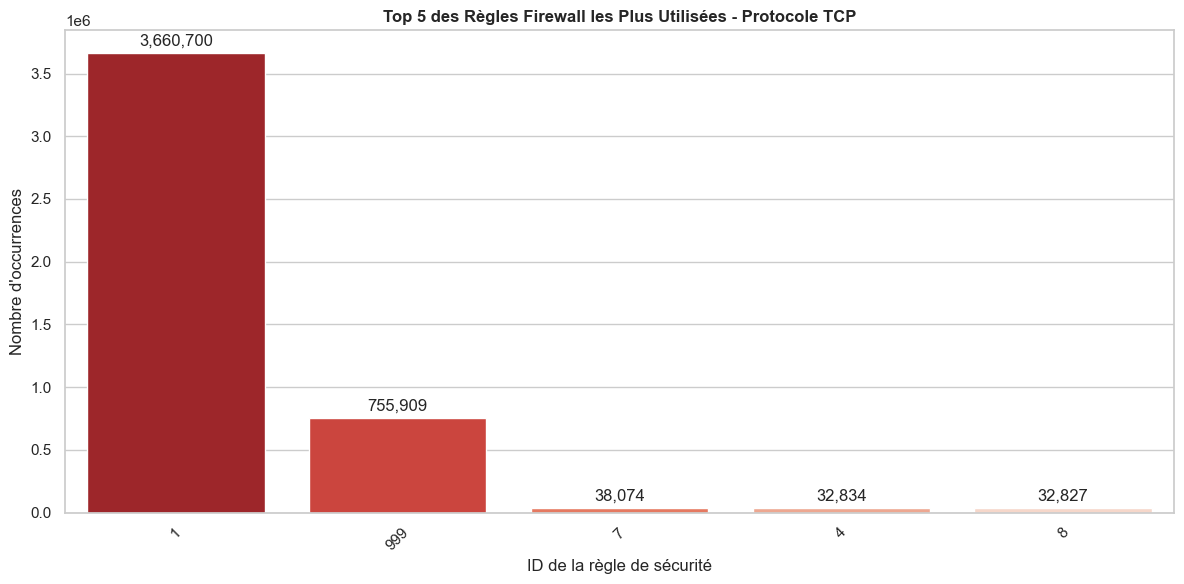

Top 5 des règles firewall TCP :
1. Règle 1: 3,660,700 occurrences
2. Règle 999: 755,909 occurrences
3. Règle 7: 38,074 occurrences
4. Règle 4: 32,834 occurrences
5. Règle 8: 32,827 occurrences


In [18]:
# Définir la colonne des règles (si pas déjà définie)
rule_col = 'rule_id'

if len(df) > 0 and rule_col in df.columns:
    # Top 10 UDP
    df_udp = df[df['protocol_deduced'] == 'UDP']
    if len(df_udp) > 0:
        top_udp = df_udp[rule_col].value_counts().head(10)
        
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x=top_udp.index.astype(str), y=top_udp.values, palette='Blues_r')
        plt.title('Top 10 des Règles Firewall les Plus Utilisées - Protocole UDP', fontweight='bold')
        plt.xlabel('ID de la règle de sécurité')
        plt.ylabel('Nombre d\'occurrences')
        plt.xticks(rotation=45)
        
        # Ajouter les valeurs sur les barres
        for i, v in enumerate(top_udp.values):
            ax.text(i, v + max(top_udp.values) * 0.01, f'{v:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("Top 10 des règles firewall UDP :")
        for idx, (rule, count) in enumerate(top_udp.items(), 1):
            print(f"{idx:2d}. Règle {rule}: {count:,} occurrences")
    else:
        print("Aucune donnée UDP trouvée.")
    
    print("\n" + "="*50 + "\n")
    
    # Top 5 TCP
    df_tcp = df[df['protocol_deduced'] == 'TCP']
    if len(df_tcp) > 0:
        top_tcp = df_tcp[rule_col].value_counts().head(5)
        
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x=top_tcp.index.astype(str), y=top_tcp.values, palette='Reds_r')
        plt.title('Top 5 des Règles Firewall les Plus Utilisées - Protocole TCP', fontweight='bold')
        plt.xlabel('ID de la règle de sécurité')
        plt.ylabel('Nombre d\'occurrences')
        plt.xticks(rotation=45)
        
        # Ajouter les valeurs sur les barres
        for i, v in enumerate(top_tcp.values):
            ax.text(i, v + max(top_tcp.values) * 0.01, f'{v:,}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("Top 5 des règles firewall TCP :")
        for idx, (rule, count) in enumerate(top_tcp.items(), 1):
            print(f"{idx}. Règle {rule}: {count:,} occurrences")
    else:
        print("Aucune donnée TCP trouvée.")
else:
    print("Pas assez de données ou colonne de règle non trouvée.")

## 5. Rapprochement Règles vs Ports Destination vs Action (TCP uniquement)

ANALYSE TCP : RAPPROCHEMENT RÈGLES - PORTS - ACTIONS
Nombre total de connexions TCP analysées : 4,572,903

TOP 20 ASSOCIATIONS RÈGLE - PORT - ACTION :
----------------------------------------------------------------------
Règle   1 | Port   443 | PERMIT | 3,621,944 occurrences
Règle   1 | Port    80 | PERMIT |  38,756 occurrences
Règle   7 | Port    23 | DENY   |  38,074 occurrences
Règle   4 | Port    22 | PERMIT |  32,834 occurrences
Règle   8 | Port    22 | PERMIT |  32,827 occurrences
Règle   6 | Port   445 | DENY   |  20,301 occurrences
Règle   9 | Port  3306 | PERMIT |   7,642 occurrences
Règle   2 | Port  3306 | PERMIT |   7,642 occurrences
Règle 999 | Port  8080 | DENY   |   7,129 occurrences
Règle   5 | Port    21 | DENY   |   6,076 occurrences
Règle  11 | Port   110 | PERMIT |   5,910 occurrences
Règle   6 | Port  3389 | DENY   |   4,058 occurrences
Règle 999 | Port  8728 | DENY   |   3,118 occurrences
Règle 999 | Port   587 | DENY   |   2,580 occurrences
Règle 999 | Port  23

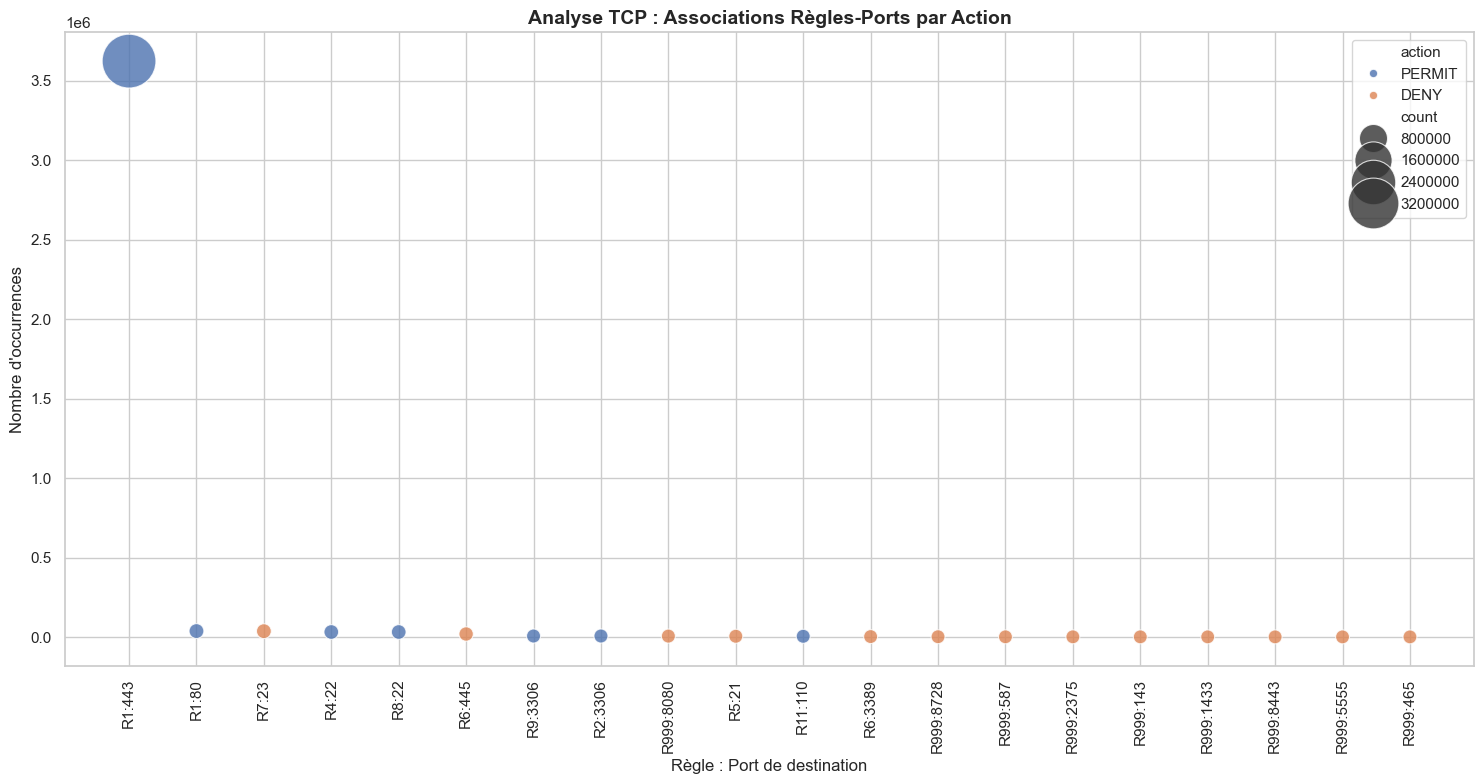


RÉPARTITION DES ACTIONS TCP PAR PORT DE DESTINATION


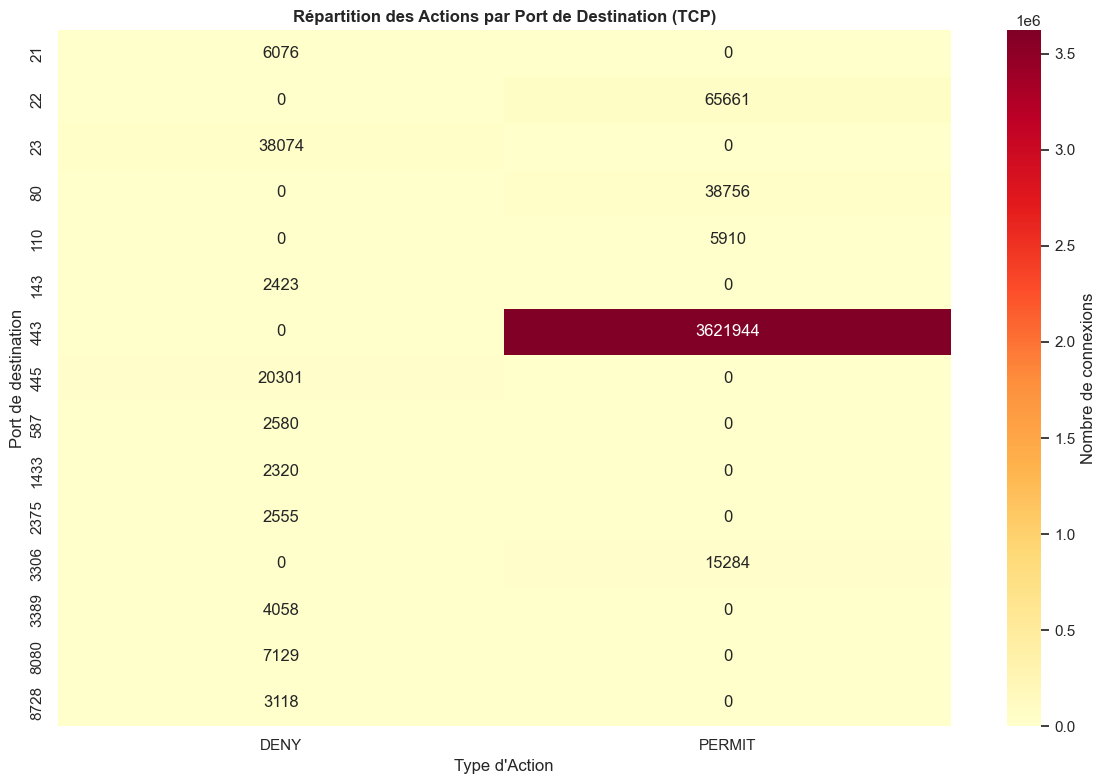


ANALYSE DES RÈGLES LES PLUS RESTRICTIVES (TCP)
Top 10 des règles les plus restrictives :
 1. Règle 6: 100.0% de refus (24,709.0 total)
 2. Règle 5: 100.0% de refus (6,656.0 total)
 3. Règle 7: 100.0% de refus (38,074.0 total)
 4. Règle 999: 100.0% de refus (755,909.0 total)
 5. Règle 2:   0.0% de refus (7,642.0 total)
 6. Règle 1:   0.0% de refus (3,660,700.0 total)
 7. Règle 4:   0.0% de refus (32,834.0 total)
 8. Règle 8:   0.0% de refus (32,827.0 total)
 9. Règle 9:   0.0% de refus (7,642.0 total)
10. Règle 11:   0.0% de refus (5,910.0 total)


In [19]:
# Analyse TCP : Rapprochement Règles vs Ports vs Actions
rule_col = 'rule_id'       # Colonne des règles firewall
dst_port_col = 'dst_port'  # Colonne des ports de destination
action_col = 'action'      # Colonne des actions (PERMIT/DENY, etc.)

if len(df) > 0 and rule_col in df.columns:
    # Filtrer sur TCP uniquement
    df_tcp = df[df['protocol_deduced'] == 'TCP'].copy()
    
    if len(df_tcp) > 0:
        print("=" * 70)
        print("ANALYSE TCP : RAPPROCHEMENT RÈGLES - PORTS - ACTIONS")
        print("=" * 70)
        print(f"Nombre total de connexions TCP analysées : {len(df_tcp):,}")
        
        # Analyse des associations Règle-Port-Action
        analysis_tcp = df_tcp.groupby([rule_col, dst_port_col, action_col]).size().reset_index(name='count')
        analysis_tcp = analysis_tcp.sort_values(by='count', ascending=False).head(20)
        
        print(f"\nTOP 20 ASSOCIATIONS RÈGLE - PORT - ACTION :")
        print("-" * 70)
        for idx, row in analysis_tcp.iterrows():
            print(f"Règle {row[rule_col]:3} | Port {row[dst_port_col]:5} | {row[action_col]:6} | {row['count']:7,} occurrences")
        
        # Graphique 1 : Scatter plot des associations
        plt.figure(figsize=(15, 8))
        analysis_tcp['rule_port'] = "R" + analysis_tcp[rule_col].astype(str) + ":" + analysis_tcp[dst_port_col].astype(str)
        
        sns.scatterplot(data=analysis_tcp, x='rule_port', y='count', hue=action_col, 
                       size='count', sizes=(100, 1500), alpha=0.8)
        plt.xticks(rotation=90)
        plt.title("Analyse TCP : Associations Règles-Ports par Action", fontsize=14, fontweight='bold')
        plt.xlabel("Règle : Port de destination")
        plt.ylabel("Nombre d'occurrences")
        plt.tight_layout()
        plt.show()
        
        # Graphique 2 : Heatmap des top ports par action
        print("\n" + "=" * 50)
        print("RÉPARTITION DES ACTIONS TCP PAR PORT DE DESTINATION")
        print("=" * 50)
        
        # Top 15 des ports les plus ciblés en TCP
        top_ports_tcp = df_tcp[dst_port_col].value_counts().head(15)
        port_action_matrix = df_tcp[df_tcp[dst_port_col].isin(top_ports_tcp.index)].groupby([dst_port_col, action_col]).size().unstack(fill_value=0)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(port_action_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                   cbar_kws={'label': 'Nombre de connexions'})
        plt.title("Répartition des Actions par Port de Destination (TCP)", fontweight='bold')
        plt.xlabel("Type d'Action")
        plt.ylabel("Port de destination")
        plt.tight_layout()
        plt.show()
        
        # Analyse supplémentaire : Règles les + restrictives pour TCP
        print("\n" + "=" * 50)
        print("ANALYSE DES RÈGLES LES PLUS RESTRICTIVES (TCP)")
        print("=" * 50)
        
        # Calcul du ratio DENY/Total par règle
        rule_actions = df_tcp.groupby([rule_col, action_col]).size().unstack(fill_value=0)
        if 'DENY' in rule_actions.columns:
            rule_actions['total'] = rule_actions.sum(axis=1)
            rule_actions['deny_ratio'] = rule_actions['DENY'] / rule_actions['total'] * 100
            top_restrictive = rule_actions.sort_values('deny_ratio', ascending=False).head(10)
            
            print("Top 10 des règles les plus restrictives :")
            for idx, (rule, data) in enumerate(top_restrictive.iterrows(), 1):
                total_rule = data['total']
                deny_pct = data['deny_ratio']
                print(f"{idx:2d}. Règle {rule}: {deny_pct:5.1f}% de refus ({total_rule:,} total)")
        
    else:
        print("Aucune donnée TCP trouvée pour l'analyse.")
else:
    print("Données insuffisantes pour l'analyse TCP ou colonne manquante.")

## 6. Graphiques de sécurité complémentaires

ANALYSES COMPLÉMENTAIRES DE SÉCURITÉ


C:\Users\olivi\AppData\Local\Temp\ipykernel_30912\1464346095.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=action_counts.index, y=action_counts.values, palette=colors[:len(action_counts)])


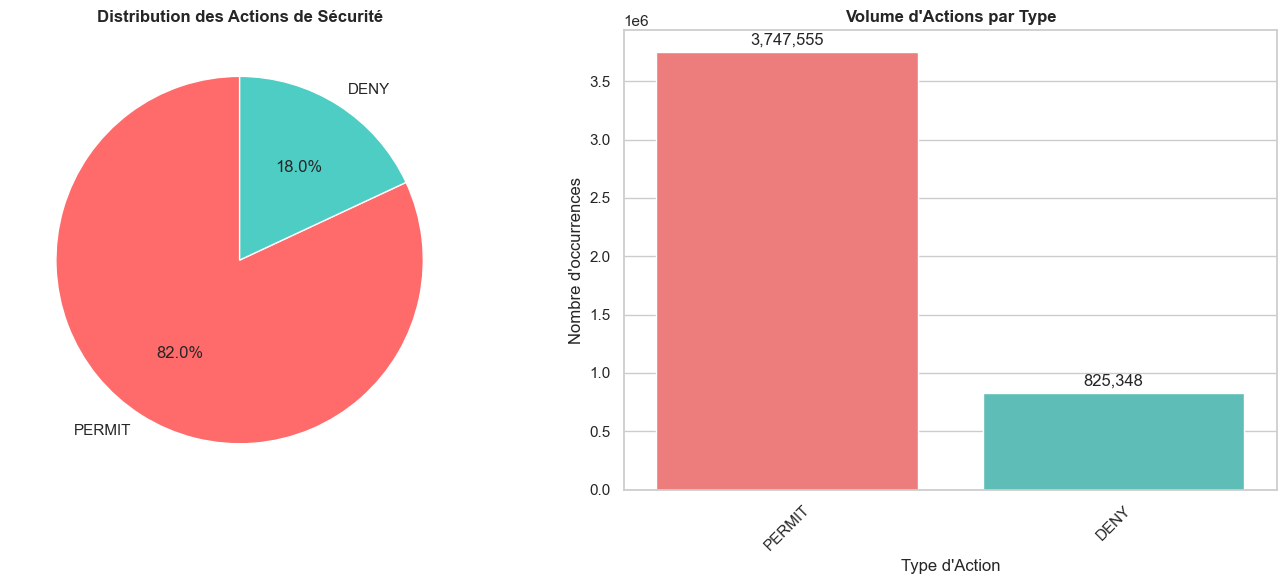


STATISTIQUES DES ACTIONS DE SÉCURITÉ :
----------------------------------------
PERMIT  : 3,747,555 ( 82.0%)
DENY    :  825,348 ( 18.0%)


2. ANALYSE TEMPORELLE DES CONNEXIONS
----------------------------------------


<Figure size 1400x600 with 0 Axes>

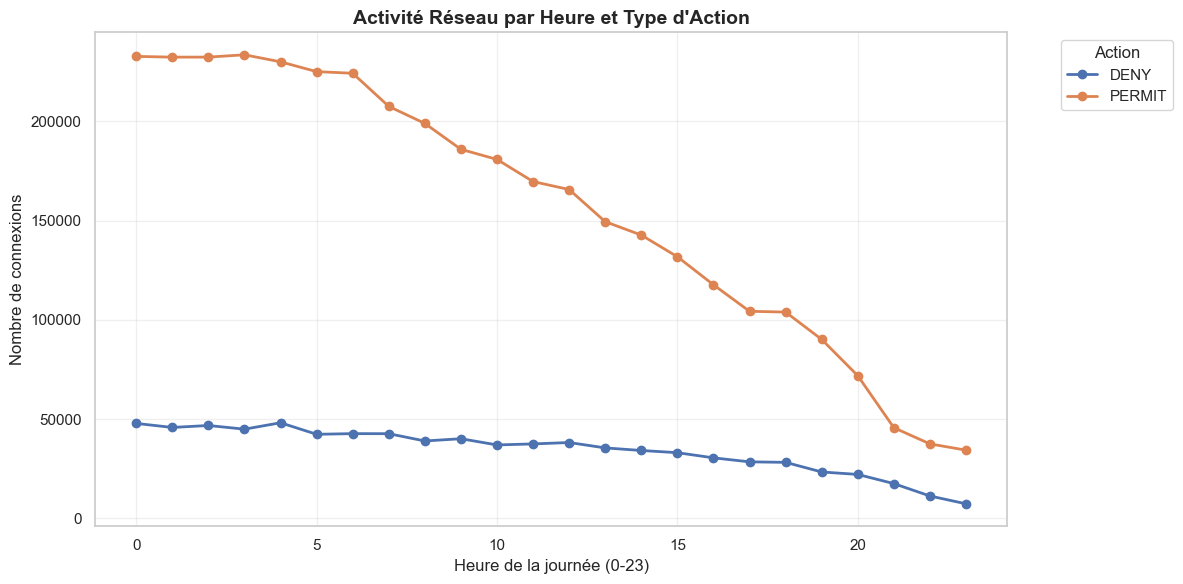

Heures de pic d'activité :
   0h00: 280,510 connexions
   2h00: 279,109 connexions
   3h00: 278,434 connexions
   1h00: 278,113 connexions
   4h00: 278,108 connexions


3. ANALYSE DES ADRESSES IP SOURCES
----------------------------------------


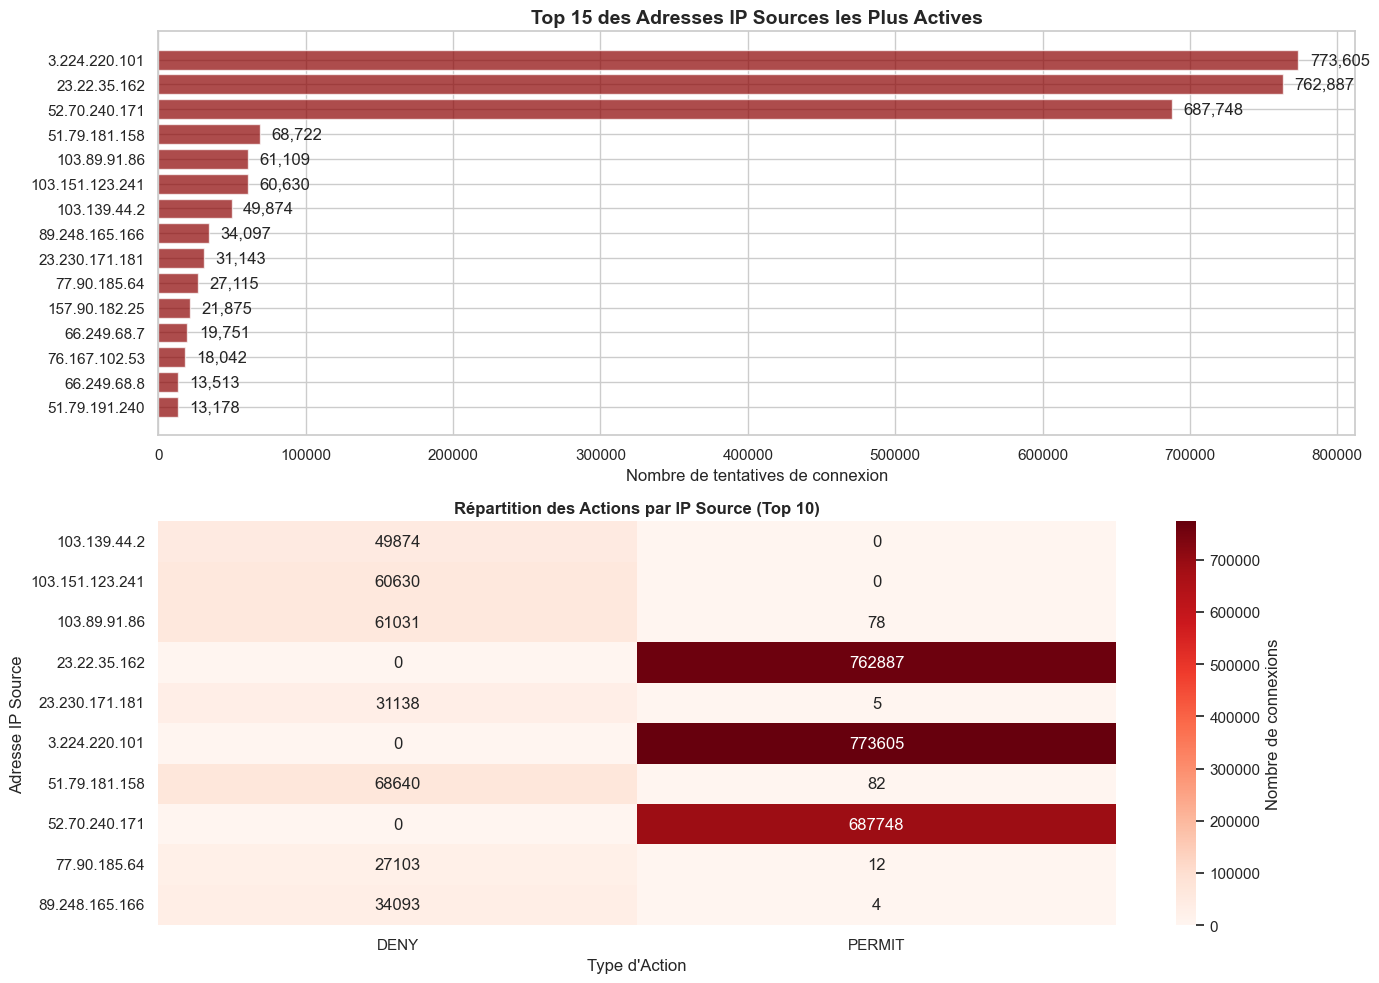


IPs les plus suspectes (fort ratio de blocages) :
 1. 103.139.44.2   : 49,874 tentatives (100.0% refusées)
 2. 103.151.123.241: 60,630 tentatives (100.0% refusées)
 3. 89.248.165.166 : 34,097 tentatives (100.0% refusées)
 4. 23.230.171.181 : 31,143 tentatives (100.0% refusées)
 5. 77.90.185.64   : 27,115 tentatives (100.0% refusées)
 6. 51.79.181.158  : 68,722 tentatives (99.9% refusées)
 7. 103.89.91.86   : 61,109 tentatives (99.9% refusées)
 8. 23.22.35.162   : 762,887 tentatives ( 0.0% refusées)
 9. 3.224.220.101  : 773,605 tentatives ( 0.0% refusées)
10. 52.70.240.171  : 687,748 tentatives ( 0.0% refusées)


4. ANALYSE DES PORTS DE DESTINATION
----------------------------------------


C:\Users\olivi\AppData\Local\Temp\ipykernel_30912\1464346095.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ports.values, y=top_ports.index.astype(str), orient='h', palette='viridis')


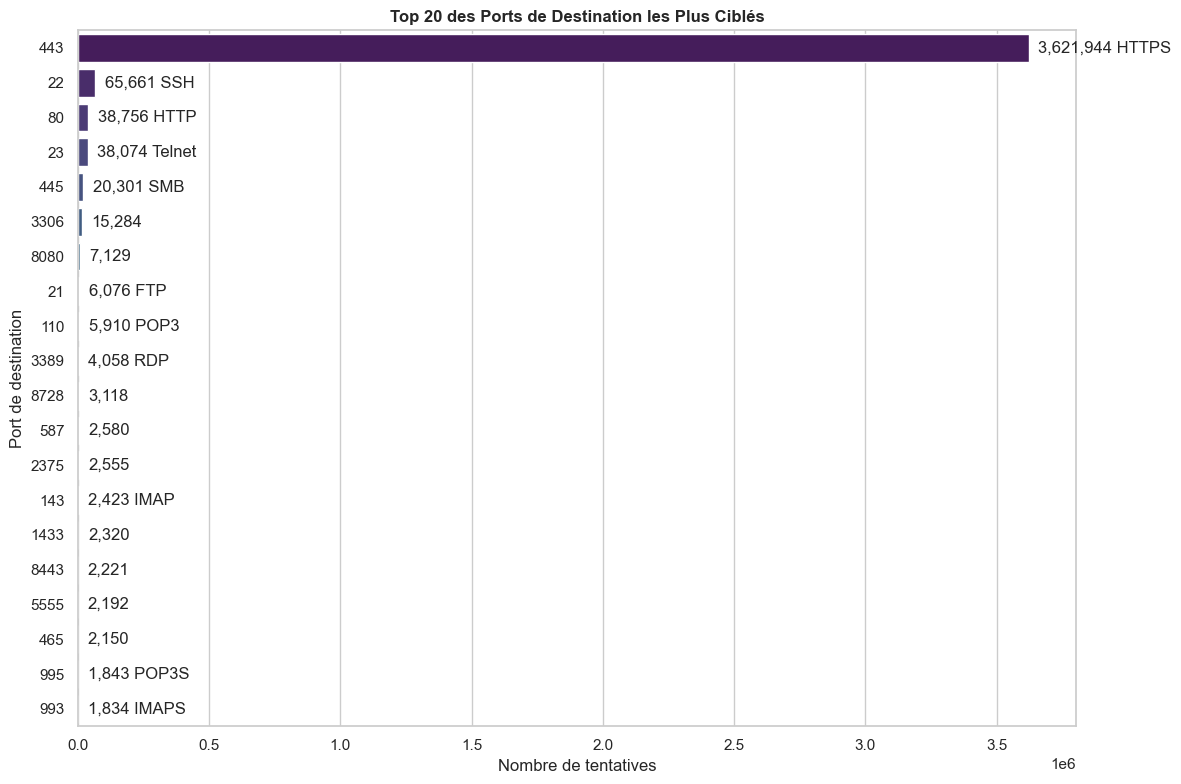

Services les plus ciblés :
 1. Port   443 (HTTPS       ): 3,621,944 tentatives (79.2%)
 2. Port    22 (SSH         ): 65,661 tentatives ( 1.4%)
 3. Port    80 (HTTP        ): 38,756 tentatives ( 0.8%)
 4. Port    23 (Telnet      ): 38,074 tentatives ( 0.8%)
 5. Port   445 (SMB         ): 20,301 tentatives ( 0.4%)
 6. Port  3306 (Service inconnu): 15,284 tentatives ( 0.3%)
 7. Port  8080 (Service inconnu):  7,129 tentatives ( 0.2%)
 8. Port    21 (FTP         ):  6,076 tentatives ( 0.1%)
 9. Port   110 (POP3        ):  5,910 tentatives ( 0.1%)
10. Port  3389 (RDP         ):  4,058 tentatives ( 0.1%)


In [23]:
if len(df) > 0:
    print("=" * 60)
    print("ANALYSES COMPLÉMENTAIRES DE SÉCURITÉ")
    print("=" * 60)
    
    # 1. Distribution des Actions de Sécurité
    plt.figure(figsize=(14, 6))
    
    # Sous-graphique 1 : Camembert
    plt.subplot(1, 2, 1)
    action_counts = df['action'].value_counts()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
    action_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=colors[:len(action_counts)])
    plt.title('Distribution des Actions de Sécurité', fontweight='bold')
    plt.ylabel('')
    
    # Sous-graphique 2 : Barres
    plt.subplot(1, 2, 2)
    ax2 = sns.barplot(x=action_counts.index, y=action_counts.values, palette=colors[:len(action_counts)])
    plt.title('Volume d\'Actions par Type', fontweight='bold')
    plt.xlabel('Type d\'Action')
    plt.ylabel('Nombre d\'occurrences')
    plt.xticks(rotation=45)
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(action_counts.values):
        ax2.text(i, v + max(action_counts.values) * 0.01, f'{v:,}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques des actions
    print(f"\nSTATISTIQUES DES ACTIONS DE SÉCURITÉ :")
    print("-" * 40)
    total_actions = action_counts.sum()
    for action, count in action_counts.items():
        percentage = (count / total_actions) * 100
        print(f"{action:8}: {count:8,} ({percentage:5.1f}%)")
    
    # 2. Analyse temporelle (par heure)
    print(f"\n\n2. ANALYSE TEMPORELLE DES CONNEXIONS")
    print("-" * 40)
    try:
        df['hour'] = df['timestamp'].dt.hour
        hourly_activity = df.groupby(['hour', 'action']).size().unstack(fill_value=0)
        
        plt.figure(figsize=(14, 6))
        hourly_activity.plot(kind='line', marker='o', linewidth=2, markersize=6)
        plt.title('Activité Réseau par Heure et Type d\'Action', fontsize=14, fontweight='bold')
        plt.xlabel('Heure de la journée (0-23)')
        plt.ylabel('Nombre de connexions')
        plt.legend(title='Action', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Identifier les heures de pic
        total_by_hour = hourly_activity.sum(axis=1)
        peak_hours = total_by_hour.nlargest(5)
        print("Heures de pic d'activité :")
        for hour, activity in peak_hours.items():
            print(f"  {hour:2d}h00: {activity:,} connexions")
            
    except Exception as e:
        print(f"Analyse temporelle non disponible: {e}")
    
    # 3. Top IPs Sources - Analyse de sécurité
    print(f"\n\n3. ANALYSE DES ADRESSES IP SOURCES")
    print("-" * 40)
    
    src_ip_col = 'src_ip'
    if src_ip_col in df.columns:
        top_src = df[src_ip_col].value_counts().head(15)
        
        plt.figure(figsize=(14, 10))
        
        # Graphique principal - Top IPs
        plt.subplot(2, 1, 1)
        bars = plt.barh(range(len(top_src)), top_src.values, color='darkred', alpha=0.7)
        plt.yticks(range(len(top_src)), top_src.index)
        plt.xlabel('Nombre de tentatives de connexion')
        plt.title('Top 15 des Adresses IP Sources les Plus Actives', fontweight='bold', fontsize=14)
        plt.gca().invert_yaxis()
        
        # Ajouter les valeurs sur les barres
        for i, (ip, count) in enumerate(top_src.items()):
            plt.text(count + max(top_src.values) * 0.01, i, f'{count:,}', va='center')
        
        # Analyse des actions par IP (Top 10 seulement pour la lisibilité)
        plt.subplot(2, 1, 2)
        top_10_src = top_src.head(10)
        top_ip_actions = df[df[src_ip_col].isin(top_10_src.index)].groupby([src_ip_col, 'action']).size().unstack(fill_value=0)
        
        sns.heatmap(top_ip_actions, annot=True, fmt='d', cmap='Reds', 
                   cbar_kws={'label': 'Nombre de connexions'})
        plt.title('Répartition des Actions par IP Source (Top 10)', fontweight='bold')
        plt.xlabel('Type d\'Action')
        plt.ylabel('Adresse IP Source')
        
        plt.tight_layout()
        plt.show()
        
        # Analyse des IPs suspectes
        print("\nIPs les plus suspectes (fort ratio de blocages) :")
        if 'DENY' in top_ip_actions.columns:
            top_ip_actions['total'] = top_ip_actions.sum(axis=1)
            top_ip_actions['deny_ratio'] = (top_ip_actions.get('DENY', 0) / top_ip_actions['total']) * 100
            suspicious_ips = top_ip_actions.sort_values('deny_ratio', ascending=False).head(10)
            
            for idx, (ip, data) in enumerate(suspicious_ips.iterrows(), 1):
                total = int(data['total'])
                deny_pct = data['deny_ratio']
                print(f"{idx:2d}. {ip:15}: {total:5,} tentatives ({deny_pct:4.1f}% refusées)")
    
    # 4. Analyse des ports les plus ciblés
    print(f"\n\n4. ANALYSE DES PORTS DE DESTINATION")
    print("-" * 40)
    
    plt.figure(figsize=(12, 8))
    top_ports = df['dst_port'].value_counts().head(20)
    
    sns.barplot(x=top_ports.values, y=top_ports.index.astype(str), orient='h', palette='viridis')
    plt.title('Top 20 des Ports de Destination les Plus Ciblés', fontweight='bold')
    plt.xlabel('Nombre de tentatives')
    plt.ylabel('Port de destination')
    
    # Annotations des services connus
    port_services = {
        80: 'HTTP', 443: 'HTTPS', 22: 'SSH', 21: 'FTP', 23: 'Telnet',
        25: 'SMTP', 53: 'DNS', 110: 'POP3', 143: 'IMAP', 3389: 'RDP',
        135: 'RPC', 139: 'NetBIOS', 445: 'SMB', 993: 'IMAPS', 995: 'POP3S'
    }
    
    for i, (port, count) in enumerate(top_ports.items()):
        service = port_services.get(int(port), '')
        label = f'{count:,} {service}' if service else f'{count:,}'
        plt.text(count + max(top_ports.values) * 0.01, i, label, va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques sur les services
    print("Services les plus ciblés :")
    for idx, (port, count) in enumerate(top_ports.head(10).items(), 1):
        service = port_services.get(int(port), 'Service inconnu')
        percentage = (count / len(df)) * 100
        print(f"{idx:2d}. Port {port:5} ({service:12}): {count:6,} tentatives ({percentage:4.1f}%)")
        
else:
    print("Aucune donnée disponible pour les analyses complémentaires.")